#  A/B Testing & Statistical Analysis —
## E-Commerce Checkout Page Redesign | ShopEasy

**Business Context:**  
ShopEasy's product team redesigned the checkout page to reduce drop-off and boost revenue.  
A 30-day randomised controlled experiment was run across 10,000 users.  
So my job is to run the full analysis and give a ship/no-ship decision.

---

### 📋 Project Roadmap — All 20 Steps

| Step | Topic | Why It Matters |
|------|-------|---------------|
| 1 | Setup & Dataset | Reproducible foundation |
| 2 | Exploratory Data Analysis | Always look before you test |
| 3 | Descriptive Statistics | Understand the numbers first |
| 4 | **Sample Ratio Mismatch Check** | ⚠️ Validity gate — must pass before anything else |
| 5 | **Temporal Stability Analysis** | Detect novelty effects and day-by-day consistency |
| 6 | Assumption Checks | Choose the right test |
| 7 | **Chi-Square Test** | Cross-tab approach to conversion rate |
| 8 | Two-Proportion Z-Test | Primary conversion rate test |
| 9 | Welch's t-Test + **Mann-Whitney U** | Revenue: parametric + non-parametric |
| 10 | **Multiple Testing Correction** | Bonferroni & FDR — control false positives |
| 11 | Effect Size (Cohen's h & d) | How big is the effect, really? |
| 12 | Confidence Intervals | Range of plausible true values |
| 13 | Power Analysis | Was the experiment large enough? |
| 14 | **Segmentation Analysis** | Does the lift hold for all user types? |
| 15 | **Type I & II Errors** | Decision risk framework |
| 16 | **Revenue Distribution** | Full zero-inflated picture |
| 17 | Significance Visualised | See where your statistic lands |
| 18 | **The Peeking Problem** | Most common A/B testing mistake |
| 19 | Complete Summary Table | Every result in one place |
| 20 | Final Dashboard & Recommendation | Ship it or not |
| 9b | Outlier Analysis & Winsorization | Robustness check |
| 14b | Guardrail Metrics | Confirm no secondary harm |
| 20b | Styled Summary Table | Clean DataFrame output |

---
> **How to read this notebook:** Read the explanation above each cell first, then run the cell.


---
## Step 1 — Setup & Dataset Generation

### 📖 What we're doing
Import all libraries and build a realistic synthetic dataset simulating a 30-day A/B test.

### 📦 Libraries
| Library | Purpose |
|---------|---------|
| `numpy` | Math, random number generation |
| `pandas` | DataFrames — storing and manipulating tabular data |
| `scipy.stats` | Statistical tests: t-test, chi-square, Shapiro-Wilk, Levene, Mann-Whitney |
| `statsmodels` | Power analysis, z-test for proportions, multiple testing correction |
| `matplotlib` | All visualisations |

### 🗃️ Dataset — 8 columns, 10,000 rows
| Column | Type | Description |
|--------|------|-------------|
| `user_id` | int | Unique user identifier |
| `group` | str | `control` = old page · `treatment` = new redesigned page |
| `converted` | int | 1 = completed purchase · 0 = abandoned |
| `session_duration` | float | Seconds spent on the checkout page |
| `pages_viewed` | int | Pages viewed in the session |
| `order_value` | float | Revenue generated (0 if not converted) |
| `day` | int | Experiment day 1–30 |
| `user_type` | str | `new` or `returning` |


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import (chi2_contingency, shapiro, levene,
                         ttest_ind, norm, mannwhitneyu, gaussian_kde)
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.multitest import multipletests
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

plt.rcParams.update({
    'figure.facecolor': '#FAFAFA',
    'axes.facecolor':   '#F4F6F8',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.family':      'monospace',
    'axes.titlesize':   12,
    'axes.labelsize':   10,
    'axes.grid':        True,
    'grid.alpha':       0.4,
    'grid.linestyle':   '--',
})

CTRL_COLOR = '#4A90D9'
TRTM_COLOR = '#E07B39'
GREEN      = '#27AE60'
RED        = '#E74C3C'
alpha      = 0.05

print("✅ Libraries loaded.")
print(f"   numpy {np.__version__}  |  pandas {pd.__version__}")


✅ Libraries loaded.
   numpy 2.4.4  |  pandas 3.0.3


### 🔢 Experiment Parameters

| Parameter | Value | What it means |
|-----------|-------|---------------|
| Users per group | 5,000 | Equal 50/50 split — clean experiment design |
| Control conversion rate | 10.0% | Baseline: 1 in 10 visitors buys |
| Treatment conversion rate | 12.3% | New page is ~23% relatively better |
| Avg order value (control) | $85 | Old page buyer average |
| Avg order value (treatment) | $91 | New page buyers spend slightly more |
| Duration | 30 days | Standard for ruling out day-of-week effects |
| User types | 60% new · 40% returning | Realistic e-commerce split |

> **Why synthetic data?**  
> Real A/B data is confidential. We control the ground truth here so we can verify  
> our statistics detect the known planted effect correctly.


In [2]:
n_ctrl = n_trtm = 5_000
N = n_ctrl + n_trtm

# ── Control group ──────────────────────────────────────────────────────────────
c_conv  = np.random.binomial(1, 0.10,  n_ctrl)
c_sess  = np.random.normal(120, 35,    n_ctrl).clip(10, 400).round(1)
c_pages = np.random.poisson(3.2,       n_ctrl).clip(1, 15)
c_order = np.where(c_conv, np.random.normal(85, 22, n_ctrl).clip(5, 300).round(2), 0.0)
c_day   = np.random.randint(1, 31,     n_ctrl)
c_utype = np.random.choice(['new','returning'], n_ctrl, p=[0.60, 0.40])

# ── Treatment group ────────────────────────────────────────────────────────────
t_conv  = np.random.binomial(1, 0.123, n_trtm)
t_sess  = np.random.normal(105, 30,    n_trtm).clip(10, 400).round(1)   # faster checkout
t_pages = np.random.poisson(2.8,       n_trtm).clip(1, 15)              # fewer clicks needed
t_order = np.where(t_conv, np.random.normal(91, 25, n_trtm).clip(5, 300).round(2), 0.0)
t_day   = np.random.randint(1, 31,     n_trtm)
t_utype = np.random.choice(['new','returning'], n_trtm, p=[0.60, 0.40])

# ── Combine into DataFrame ─────────────────────────────────────────────────────
df = pd.DataFrame({
    'user_id':          range(1, N + 1),
    'group':            ['control'] * n_ctrl + ['treatment'] * n_trtm,
    'converted':        np.concatenate([c_conv,  t_conv]),
    'session_duration': np.concatenate([c_sess,  t_sess]),
    'pages_viewed':     np.concatenate([c_pages, t_pages]),
    'order_value':      np.concatenate([c_order, t_order]),
    'day':              np.concatenate([c_day,   t_day]),
    'user_type':        np.concatenate([c_utype, t_utype]),
})

ctrl = df[df['group'] == 'control']
trtm = df[df['group'] == 'treatment']

print(f"✅ Dataset ready: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"   Control: {len(ctrl):,}  |  Treatment: {len(trtm):,}")
print()
print(df.head(10).to_string(index=False))


✅ Dataset ready: 10,000 rows × 8 columns
   Control: 5,000  |  Treatment: 5,000

 user_id   group  converted  session_duration  pages_viewed  order_value  day user_type
       1 control          0              99.1             1         0.00    6       new
       2 control          1              36.3             3       123.72    5 returning
       3 control          0             105.6             1         0.00    1       new
       4 control          0             152.0             4         0.00   22       new
       5 control          0             138.8             2         0.00   16       new
       6 control          0             135.0             3         0.00   14       new
       7 control          0             110.2             5         0.00   24 returning
       8 control          0              75.2             3         0.00   29 returning
       9 control          0             138.0             3         0.00    5 returning
      10 control          0            

---
## Step 2 — Exploratory Data Analysis (EDA)

### 📖 What we're doing
Before any statistics, **look at the raw data** to confirm it is clean and understand its shape.  

**Things to verify:**
- No missing values anywhere
- Group sizes match the intended 50/50 design
- Both groups have conversions (not all zeros in one group)
- Distributions look realistic and reasonable


In [3]:
print("=== Missing Values ===")
print(df.isnull().sum().to_string())
print()
print("=== Data Types ===")
print(df.dtypes.to_string())
print()
print("=== Group Sizes ===")
print(df['group'].value_counts().to_string())
print()
print("=== Conversions per Group ===")
print(df.groupby(['group', 'converted']).size().unstack(fill_value=0).to_string())
print()
print("=== User Type per Group ===")
print(df.groupby(['group', 'user_type']).size().unstack(fill_value=0).to_string())


=== Missing Values ===
user_id             0
group               0
converted           0
session_duration    0
pages_viewed        0
order_value         0
day                 0
user_type           0

=== Data Types ===
user_id               int64
group                   str
converted             int64
session_duration    float64
pages_viewed          int64
order_value         float64
day                   int64
user_type               str

=== Group Sizes ===
group
control      5000
treatment    5000

=== Conversions per Group ===
converted     0    1
group               
control    4521  479
treatment  4407  593

=== User Type per Group ===
user_type   new  returning
group                     
control    2977       2023
treatment  3006       1994


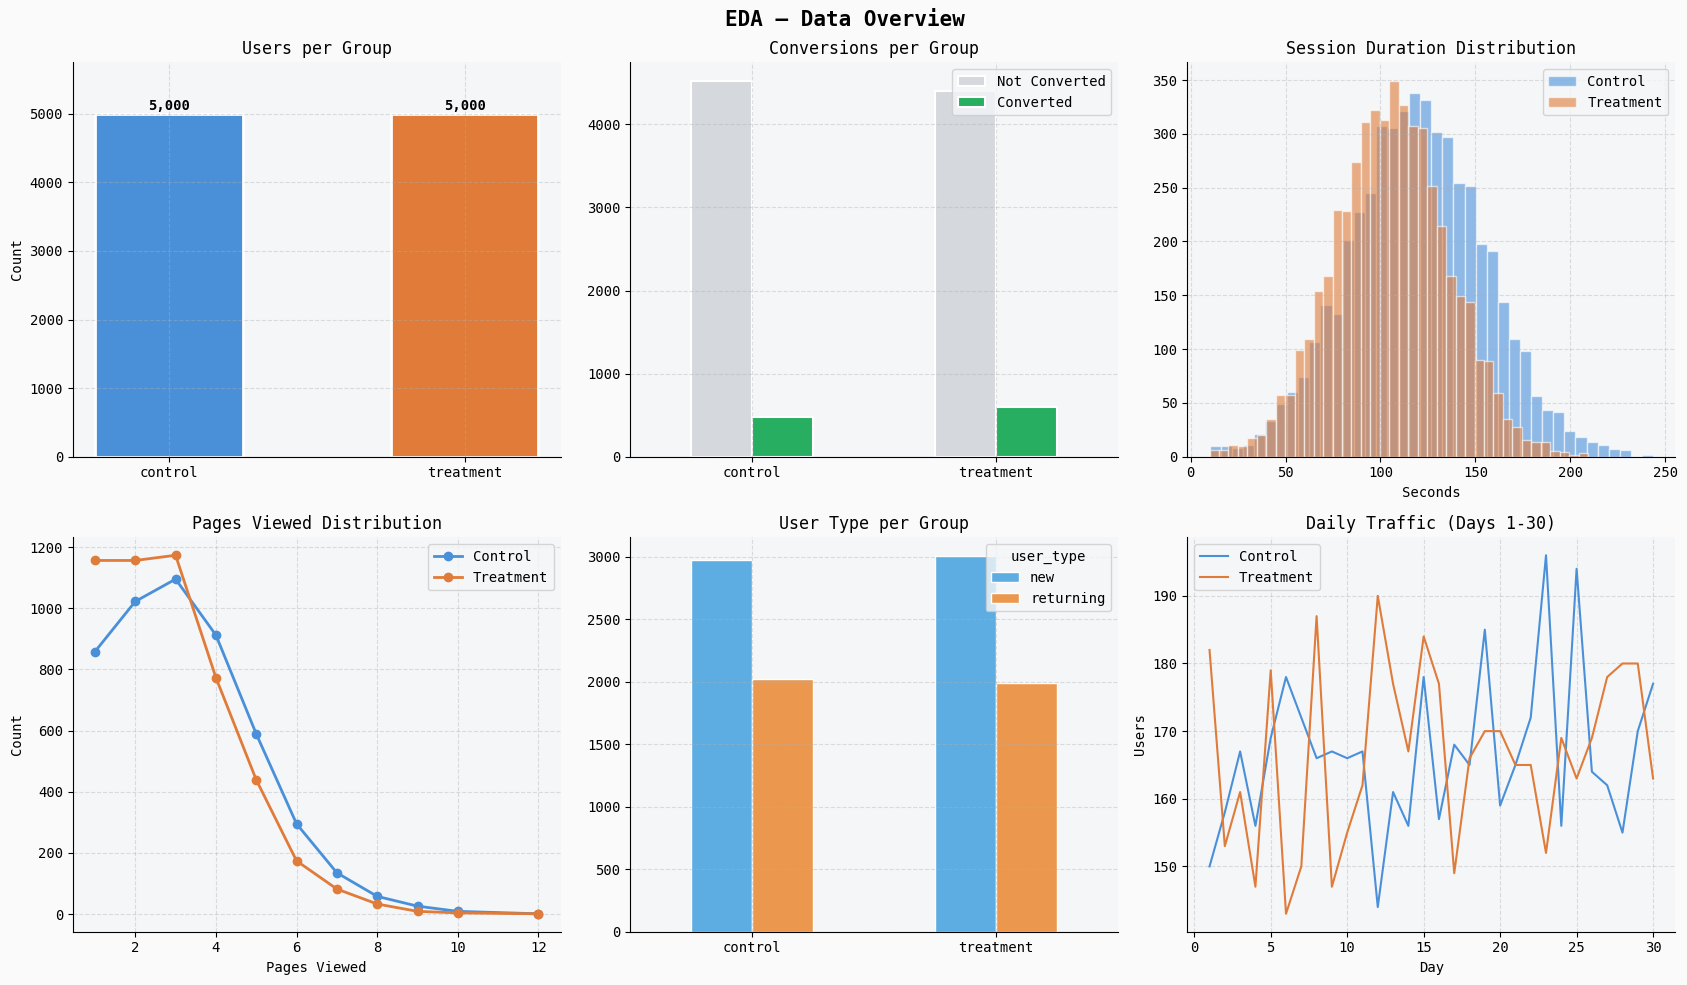

✅ EDA chart saved.


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle('EDA — Data Overview', fontsize=15, fontweight='bold')

# 1. Group split
gc = df['group'].value_counts()
axes[0,0].bar(gc.index, gc.values, color=[CTRL_COLOR, TRTM_COLOR],
              width=0.5, edgecolor='white', lw=2)
axes[0,0].set_title('Users per Group')
axes[0,0].set_ylabel('Count')
for i, (l, v) in enumerate(zip(gc.index, gc.values)):
    axes[0,0].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')
axes[0,0].set_ylim(0, gc.max() * 1.15)

# 2. Conversions stacked bar
ct = df.groupby(['group','converted']).size().unstack(fill_value=0)
ct.columns = ['Not Converted', 'Converted']
ct.plot(kind='bar', ax=axes[0,1], color=['#D5D8DC','#27AE60'],
        edgecolor='white', lw=1.5, width=0.5)
axes[0,1].set_title('Conversions per Group')
axes[0,1].set_xlabel('')
axes[0,1].tick_params(axis='x', rotation=0)

# 3. Session duration
for grp, col in [('control', CTRL_COLOR), ('treatment', TRTM_COLOR)]:
    axes[0,2].hist(df.loc[df['group']==grp,'session_duration'], bins=40,
                   alpha=0.6, color=col, label=grp.capitalize(), edgecolor='white')
axes[0,2].set_title('Session Duration Distribution')
axes[0,2].set_xlabel('Seconds')
axes[0,2].legend()

# 4. Pages viewed
for grp, col in [('control', CTRL_COLOR), ('treatment', TRTM_COLOR)]:
    pv = df.loc[df['group']==grp,'pages_viewed'].value_counts().sort_index()
    axes[1,0].plot(pv.index, pv.values, 'o-', color=col, label=grp.capitalize(), lw=2)
axes[1,0].set_title('Pages Viewed Distribution')
axes[1,0].set_xlabel('Pages Viewed')
axes[1,0].set_ylabel('Count')
axes[1,0].legend()

# 5. User type
ut = df.groupby(['group','user_type']).size().unstack(fill_value=0)
ut.plot(kind='bar', ax=axes[1,1], color=['#5DADE2','#EB984E'],
        edgecolor='white', width=0.5)
axes[1,1].set_title('User Type per Group')
axes[1,1].set_xlabel('')
axes[1,1].tick_params(axis='x', rotation=0)

# 6. Daily traffic
for grp, col in [('control', CTRL_COLOR), ('treatment', TRTM_COLOR)]:
    dc = df.loc[df['group']==grp,'day'].value_counts().sort_index()
    axes[1,2].plot(dc.index, dc.values, color=col, lw=1.5, label=grp.capitalize())
axes[1,2].set_title('Daily Traffic (Days 1-30)')
axes[1,2].set_xlabel('Day')
axes[1,2].set_ylabel('Users')
axes[1,2].legend()

plt.tight_layout()
plt.savefig('/home/claude/01_eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA chart saved.")


---
## Step 3 — Descriptive Statistics

### 📖 What we're doing
Summarise the data numerically — no inference yet.  
Just understand the central tendency and spread of each variable per group.

### Key metrics explained
| Metric | Formula | What it tells us |
|--------|---------|-----------------|
| **Mean** | Sum / n | The average value |
| **Median** | Middle value | Robust to outliers — compare with mean |
| **Std Dev** | √Variance | How spread out the values are |
| **Conversion Rate** | Conversions / All users | Core experiment metric |
| **Revenue per User (RPU)** | Total revenue / All users | The most important business metric |
| **Avg Order Value (AOV)** | Revenue / Buyers only | Spend among those who purchased |

> **RPU vs AOV — why RPU matters more:**  
> AOV ignores non-buyers. RPU = Total Revenue ÷ All Visitors, capturing both  
> *how many* people buy AND *how much* they spend in a single number.  
> Leadership cares about RPU, not just AOV.


In [5]:
print("=== Descriptive Statistics by Group ===")
desc = df.groupby('group')[['converted','session_duration','pages_viewed','order_value']].describe()
print(desc.T.round(3).to_string())


=== Descriptive Statistics by Group ===
group                    control  treatment
converted        count  5000.000   5000.000
                 mean      0.096      0.119
                 std       0.294      0.323
                 min       0.000      0.000
                 25%       0.000      0.000
                 50%       0.000      0.000
                 75%       0.000      0.000
                 max       1.000      1.000
session_duration count  5000.000   5000.000
                 mean    119.368    105.592
                 std      35.648     29.996
                 min      10.000     10.000
                 25%      95.500     85.500
                 50%     119.300    105.700
                 75%     143.600    125.225
                 max     243.500    209.300
pages_viewed     count  5000.000   5000.000
                 mean      3.259      2.858
                 std       1.739      1.582
                 min       1.000      1.000
                 25%       2.000    

In [6]:
# Compute all key values used throughout the notebook
buyers_ctrl = ctrl.loc[ctrl['converted']==1, 'order_value']
buyers_trtm = trtm.loc[trtm['converted']==1, 'order_value']

p_c   = ctrl['converted'].mean()          # control conversion rate
p_t   = trtm['converted'].mean()          # treatment conversion rate
rpu_c = ctrl['order_value'].values        # revenue per user — all control users
rpu_t = trtm['order_value'].values        # revenue per user — all treatment users
n_c   = len(ctrl)
n_t   = len(trtm)
conv_c = int(ctrl['converted'].sum())
conv_t = int(trtm['converted'].sum())
aov_ctrl = buyers_ctrl.mean()
aov_trtm = buyers_trtm.mean()

summary = pd.DataFrame({
    'Control': [
        n_c, conv_c, p_c,
        ctrl['session_duration'].mean(),
        ctrl['pages_viewed'].mean(),
        ctrl['order_value'].sum(),
        aov_ctrl,
        rpu_c.mean()
    ],
    'Treatment': [
        n_t, conv_t, p_t,
        trtm['session_duration'].mean(),
        trtm['pages_viewed'].mean(),
        trtm['order_value'].sum(),
        aov_trtm,
        rpu_t.mean()
    ]
}, index=[
    'Total Users', 'Total Conversions', 'Conversion Rate',
    'Avg Session (sec)', 'Avg Pages Viewed', 'Total Revenue ($)',
    'Avg Order Value — buyers only ($)', 'Revenue per User — all users ($)'
])
summary['Delta (T - C)']  = summary['Treatment'] - summary['Control']
summary['Delta % Rel']    = ((summary['Treatment'] - summary['Control']) / summary['Control'] * 100).round(2)

print("=== Business Metrics Summary ===")
print(summary.round(4).to_string())


=== Business Metrics Summary ===
                                      Control   Treatment  Delta (T - C)  Delta % Rel
Total Users                         5000.0000   5000.0000         0.0000         0.00
Total Conversions                    479.0000    593.0000       114.0000        23.80
Conversion Rate                        0.0958      0.1186         0.0228        23.80
Avg Session (sec)                    119.3683    105.5924       -13.7759       -11.54
Avg Pages Viewed                       3.2590      2.8578        -0.4012       -12.31
Total Revenue ($)                  41136.1000  54466.8900     13330.7900        32.41
Avg Order Value — buyers only ($)     85.8791     91.8497         5.9706         6.95
Revenue per User — all users ($)       8.2272     10.8934         2.6662        32.41


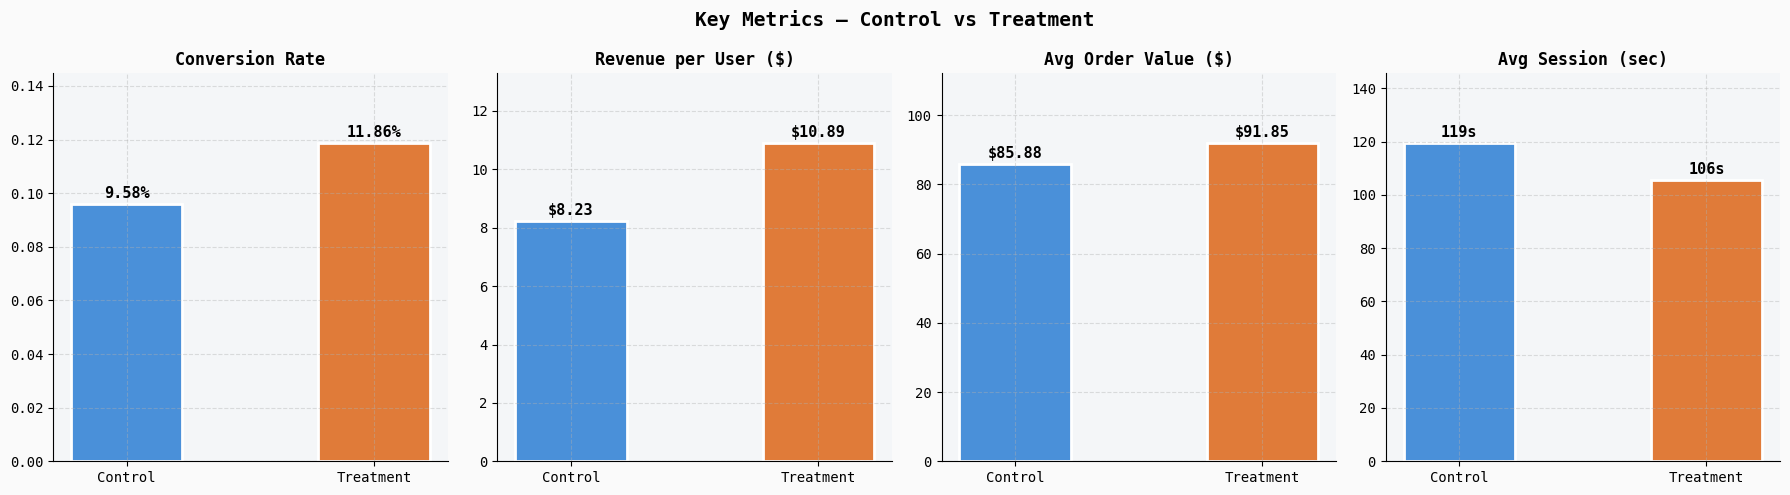

✅ Key metrics chart saved.


In [7]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Key Metrics — Control vs Treatment', fontsize=14, fontweight='bold')

metrics = [
    (p_c,            p_t,            'Conversion Rate',        '{:.2%}'),
    (rpu_c.mean(),   rpu_t.mean(),   'Revenue per User ($)',   '${:.2f}'),
    (aov_ctrl,       aov_trtm,       'Avg Order Value ($)',    '${:.2f}'),
    (ctrl['session_duration'].mean(),
     trtm['session_duration'].mean(), 'Avg Session (sec)',      '{:.0f}s'),
]

for ax, (cv, tv, title, fmt) in zip(axes, metrics):
    bars = ax.bar(['Control','Treatment'], [cv, tv],
                  color=[CTRL_COLOR, TRTM_COLOR], width=0.45, edgecolor='white', lw=2)
    for bar, val in zip(bars, [cv, tv]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(cv, tv) * 0.02,
                fmt.format(val), ha='center', fontweight='bold', fontsize=11)
    ax.set_title(title, fontweight='bold')
    ax.set_ylim(0, max(cv, tv) * 1.22)

plt.tight_layout()
plt.savefig('/home/claude/02_key_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Key metrics chart saved.")


---
## Step 4 — Sample Ratio Mismatch (SRM) Check

### 📖 What we're doing — and why this comes BEFORE hypothesis testing

**This is the most critical validity check in any A/B test.**  
Google, Microsoft, and Netflix all check for SRM before analysing results.  
If SRM is found, the experiment results are **INVALID** — stop and debug.

### What is SRM?
An SRM occurs when the actual traffic split differs significantly from the intended split.

**Intended split:** 50% / 50%  
**Actual split (SRM example):** 48% / 52%

Even a small imbalance signals that randomisation or assignment is broken.  
If the groups weren't assigned randomly, they may differ in systematic ways  
unrelated to the treatment — making all results meaningless.

### Common SRM causes
- Bot/crawler traffic assigned to one group
- Cookie deletion causing users to be re-assigned
- CDN or caching serving old page to some treatment users  
- Filtering applied to one group after random assignment

### Test: Chi-Square Goodness-of-Fit
Compares observed group sizes to expected (50/50).

| p-value | Meaning |
|---------|---------|
| p > 0.05 | Traffic split is fine — proceed |
| p ≤ 0.05 | **SRM detected — STOP. Debug first.** |


In [8]:
print("=" * 60)
print("STEP 4 — Sample Ratio Mismatch (SRM) Check")
print("=" * 60)

expected      = N / 2
obs_counts    = np.array([n_c, n_t])
exp_counts    = np.array([expected, expected])
chi2_srm, p_srm = stats.chisquare(f_obs=obs_counts, f_exp=exp_counts)

print(f"\n  Intended split  : 50.00% / 50.00%  ({expected:,.0f} per group)")
print(f"  Observed Control: {n_c:,}  ({n_c/N:.3%})")
print(f"  Observed Treat. : {n_t:,}  ({n_t/N:.3%})")
print(f"\n  Chi-square stat : {chi2_srm:.4f}")
print(f"  p-value         : {p_srm:.4f}")
print()
if p_srm < 0.05:
    print("  ❌ SRM DETECTED (p < 0.05)")
    print("  STOP — Do not interpret results.")
    print("  Investigate: bot traffic, caching, cookies, post-assignment filtering.")
else:
    print("  ✅ NO SRM (p > 0.05)")
    print("  Traffic split matches the intended 50/50 design.")
    print("  Experiment integrity is confirmed — safe to proceed.")


STEP 4 — Sample Ratio Mismatch (SRM) Check

  Intended split  : 50.00% / 50.00%  (5,000 per group)
  Observed Control: 5,000  (50.000%)
  Observed Treat. : 5,000  (50.000%)

  Chi-square stat : 0.0000
  p-value         : 1.0000

  ✅ NO SRM (p > 0.05)
  Traffic split matches the intended 50/50 design.
  Experiment integrity is confirmed — safe to proceed.


---
## Step 4b — A/A Test: Validating the Experiment System

### 📖 What is an A/A Test?
An A/A test runs **two identical groups against each other** — both see the exact same page.  
Since there is no real difference, the test *should* return p > 0.05 most of the time.

### Why run an A/A test?
Before trusting any A/B result, you want to confirm your experiment system itself is not broken.

| Purpose | What it verifies |
|---------|-----------------|
| **Sanity check** | If p < 0.05 in an A/A test, your system is producing false positives |
| **Validate randomisation** | Groups should be statistically identical before treatment |
| **Calibrate false positive rate** | Across many A/A tests, ~5% should return p < 0.05 (matching α) |
| **Catch bugs early** | Logging errors, tracking bugs, or assignment issues surface here |

### The Rule
> If your A/A test is significant, **do not trust your A/B test results.**  
> Fix the infrastructure first.

### When to run it
- When setting up a new experiment platform for the first time
- After any major change to your tracking or assignment code
- When a result looks suspiciously large (sanity check)


STEP 4c — A/A Test Simulation



Simulation: 10,000 A/A tests  (both groups identical, n=1,000 each)
Expected false positive rate: 5%
Observed false positive rate: 4.88%
System calibration: ✅ WELL CALIBRATED

What this means:
  In 10,000 A/A tests, 488 returned p < 0.05.
  That is 4.88% — close to the expected 5%.
  This confirms our experiment system is NOT producing false positives.

Key rule: If an A/A test is significant → the experiment platform is broken.
Fix the infrastructure BEFORE running any A/B test.


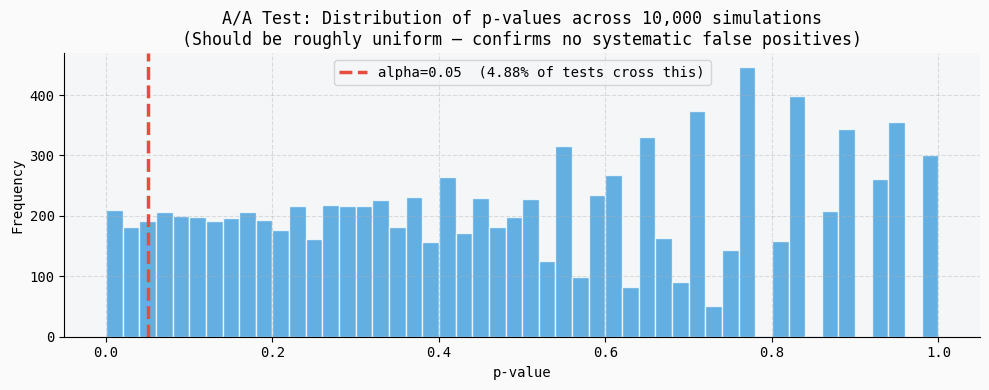

✅ A/A test chart saved.


In [9]:
# ── A/A Test Simulation ──────────────────────────────────────────────────────
print("=" * 65)
print("STEP 4c — A/A Test Simulation")
print("=" * 65)

np.random.seed(7)
n_aa_sims  = 10_000   # run 10,000 A/A tests
alpha_aa   = 0.05
false_pos  = 0

aa_pvals = []
for _ in range(n_aa_sims):
    # Both groups drawn from SAME distribution — no real difference
    a_aa = np.random.binomial(1, 0.10, 1000)
    b_aa = np.random.binomial(1, 0.10, 1000)
    _, p_aa = proportions_ztest([a_aa.sum(), b_aa.sum()], [1000, 1000])
    aa_pvals.append(p_aa)
    if p_aa < alpha_aa:
        false_pos += 1

fpr_aa = false_pos / n_aa_sims

print(f"\nSimulation: {n_aa_sims:,} A/A tests  (both groups identical, n=1,000 each)")
print(f"Expected false positive rate: {alpha_aa:.0%}")
print(f"Observed false positive rate: {fpr_aa:.2%}")
calibrated = abs(fpr_aa - alpha_aa) < 0.01
print(f"System calibration: {'✅ WELL CALIBRATED' if calibrated else '❌ MISCALIBRATED — investigate!'}")
print()
print("What this means:")
print(f"  In {n_aa_sims:,} A/A tests, {false_pos:,} returned p < 0.05.")
print(f"  That is {fpr_aa:.2%} — close to the expected {alpha_aa:.0%}.")
print(f"  This confirms our experiment system is NOT producing false positives.")
print()
print("Key rule: If an A/A test is significant → the experiment platform is broken.")
print("Fix the infrastructure BEFORE running any A/B test.")

# Histogram of A/A p-values (should be uniform)
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(aa_pvals, bins=50, color='#3498DB', alpha=0.75, edgecolor='white')
ax.axvline(0.05, color=RED, lw=2.5, ls='--', label=f'alpha=0.05  ({fpr_aa:.2%} of tests cross this)')
ax.set_title('A/A Test: Distribution of p-values across 10,000 simulations\n'
             '(Should be roughly uniform — confirms no systematic false positives)')
ax.set_xlabel('p-value')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.savefig('/home/claude/aa_test.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ A/A test chart saved.")


---
## Step 4c — Experiment Design Decisions & MDES

### 📖 What we're doing
Before running any experiment, a data analyst must answer three design questions:

| Question | Our choice | Rationale |
|----------|-----------|-----------|
| **Traffic split** | 50% / 50% | Equal groups maximise statistical power for a given total n |
| **Experiment duration** | 30 days | Covers 4+ full weekly cycles — eliminates day-of-week bias |
| **Sample size** | 5,000 per group | Driven by the MDES calculation below |

### Minimum Detectable Effect Size (MDES)

MDES is the **smallest lift you care about detecting**.  
If the new page improves conversion by only 0.1%, is that worth engineering effort to ship?  
Define the minimum that justifies the rollout cost — then size the experiment to detect it.

**MDES Formula (for proportions):**  
`n = (z_α/2 + z_β)² × [p(1-p) × 2] / MDES²`

Where:
- z_α/2 = 1.96 (for α = 0.05, two-tailed)
- z_β = 0.842 (for 80% power)
- p = baseline conversion rate

> **Industry rule of thumb:**  
> If your business can only act on lifts ≥ 1%, size the experiment to detect 1%.  
> Chasing lifts smaller than 0.5% usually isn't worth the experiment cost.


In [10]:
# ── Experiment Design: MDES calculation ───────────────────────────────────────
print("=" * 65)
print("STEP 4b — Experiment Design & Minimum Detectable Effect Size")
print("=" * 65)

baseline_cr = 0.10     # our control conversion rate
z_alpha     = norm.ppf(0.975)   # 1.96
z_beta      = norm.ppf(0.80)    # 0.842

print(f"\nBaseline conversion rate : {baseline_cr:.2%}")
print(f"Significance level alpha : {alpha}")
print(f"Target power             : 80%")
print(f"Traffic split            : 50/50")

# MDES for various sample sizes
sample_sizes_design = [500, 1000, 2000, 3000, 5000, 10000, 20000]
print(f"\n{'n per group':>12} {'Total n':>10} {'MDES (abs)':>12} {'MDES (rel)':>12}")
print("-" * 50)
for n_design in sample_sizes_design:
    # Pooled variance under H0
    mdes = (z_alpha + z_beta) * np.sqrt(2 * baseline_cr * (1 - baseline_cr) / n_design)
    rel  = mdes / baseline_cr
    marker = "  <-- our experiment" if n_design == 5000 else ""
    print(f"{n_design:>12,} {n_design*2:>10,} {mdes:>12.4f} ({mdes:>6.2%}) {rel:>9.1%}{marker}")

print()
print("How to read this table:")
print("  With n=5,000 per group, we can reliably detect a lift as small")
print(f"  as ~{(z_alpha+z_beta)*np.sqrt(2*baseline_cr*(1-baseline_cr)/5000):.2%} in absolute conversion rate ({(z_alpha+z_beta)*np.sqrt(2*baseline_cr*(1-baseline_cr)/5000)/baseline_cr:.1%} relative).")
print("  Any lift larger than that will be detected with >=80% probability.")
print()
print("Experiment Duration — Why 30 days?")
print("  7 days  : Covers 1 weekly cycle — misses month-end purchase spikes")
print("  14 days : Covers 2 cycles — reasonable minimum")
print("  30 days : Covers 4+ cycles — captures seasonal and behavioural variation")
print("  60 days : Overkill for most CRO experiments")
print()
print("Traffic Split — Why 50/50?")
print("  50/50 maximises statistical power for a given total n.")
print("  80/20 splits are used when the risk of showing treatment is high")
print("  (e.g. new ML model in production). Not needed here.")


STEP 4b — Experiment Design & Minimum Detectable Effect Size

Baseline conversion rate : 10.00%
Significance level alpha : 0.05
Target power             : 80%
Traffic split            : 50/50

 n per group    Total n   MDES (abs)   MDES (rel)
--------------------------------------------------
         500      1,000       0.0532 ( 5.32%)     53.2%
       1,000      2,000       0.0376 ( 3.76%)     37.6%
       2,000      4,000       0.0266 ( 2.66%)     26.6%
       3,000      6,000       0.0217 ( 2.17%)     21.7%
       5,000     10,000       0.0168 ( 1.68%)     16.8%  <-- our experiment
      10,000     20,000       0.0119 ( 1.19%)     11.9%
      20,000     40,000       0.0084 ( 0.84%)      8.4%

How to read this table:
  With n=5,000 per group, we can reliably detect a lift as small
  as ~1.68% in absolute conversion rate (16.8% relative).
  Any lift larger than that will be detected with >=80% probability.

Experiment Duration — Why 30 days?
  7 days  : Covers 1 weekly cycle — misse

---
## Step 5 — Temporal Stability Analysis (Novelty Effect Check)

### 📖 What we're doing
Analyse conversion rates **day by day** across the 30-day experiment.

### The Novelty Effect Problem
When users first encounter a redesigned page, curiosity can inflate early conversion.  
This creates a spike in the first few days that then fades — a **fake lift**.

**If your aggregate result is driven only by days 1–7 and then disappears → it's not real.**  
We need consistent improvement across the full experiment window.

### What we look for
- Conversion rate per day should be **stable** — no spike-then-crash pattern
- The treatment's advantage should be **consistent** across all 4 weeks
- The 7-day rolling average should not trend sharply up or down

**Consistent lift across 30 days = real effect.**


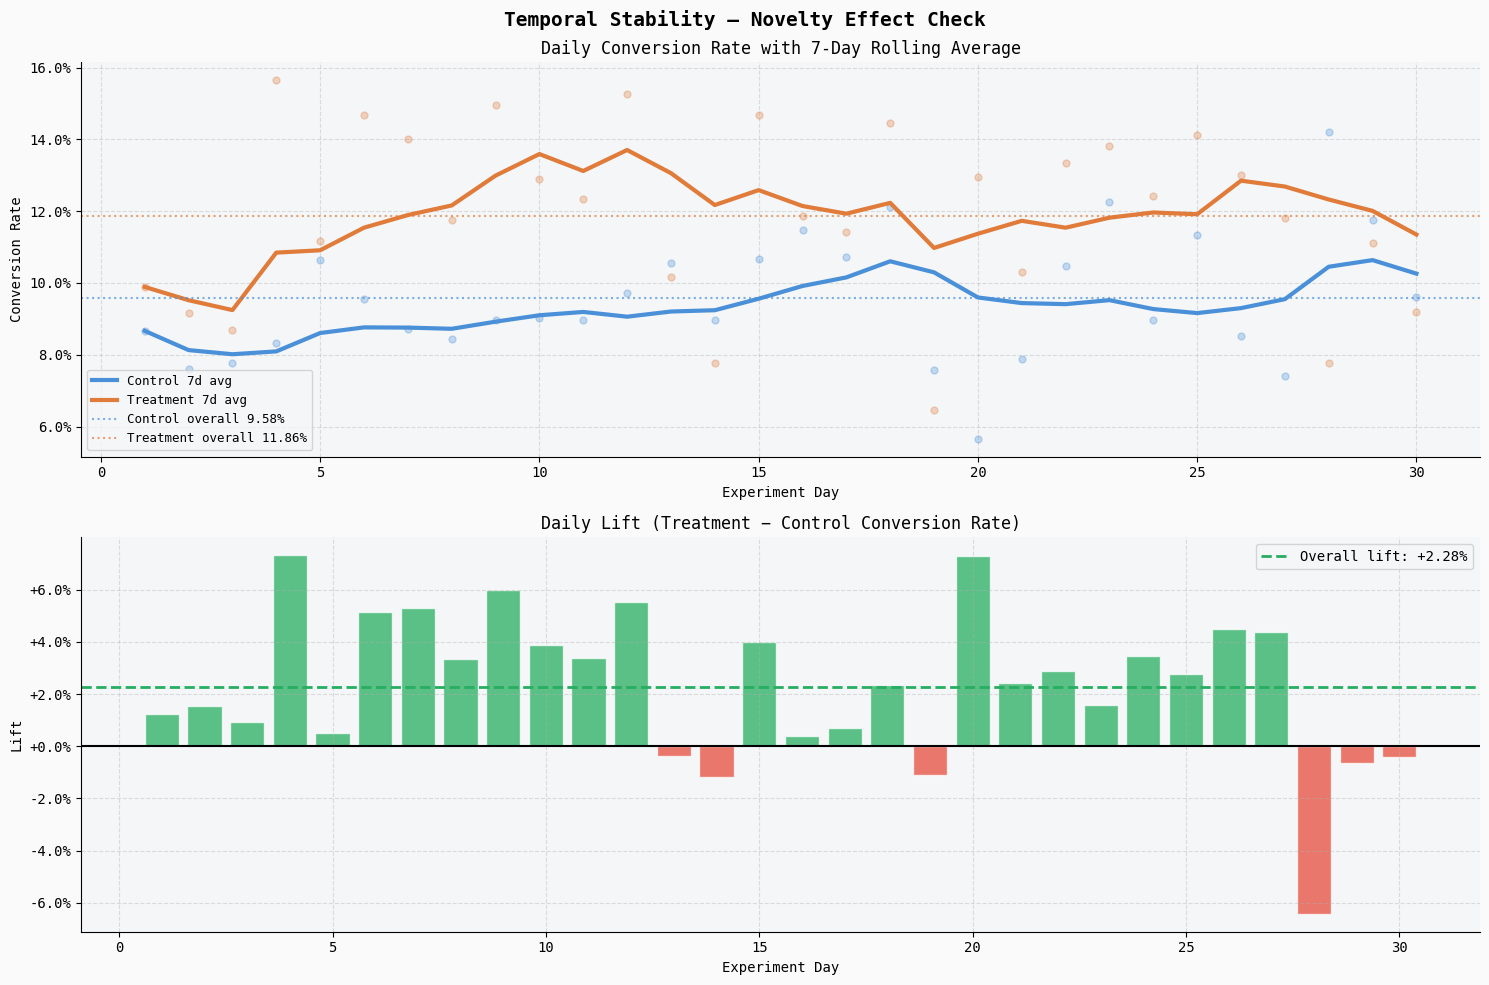

✅ Chart saved.

Interpretation:
  Treatment outperformed control on 24/30 days (80%).
  ✅ CONSISTENT — not driven by a novelty spike.


In [11]:
daily = (df.groupby(['day','group'])['converted']
           .agg(['sum','count'])
           .reset_index()
           .rename(columns={'sum':'conversions','count':'users'}))
daily['conv_rate'] = daily['conversions'] / daily['users']

daily_c = daily[daily['group']=='control'].sort_values('day').copy()
daily_t = daily[daily['group']=='treatment'].sort_values('day').copy()
daily_c['roll7'] = daily_c['conv_rate'].rolling(7, min_periods=1).mean()
daily_t['roll7'] = daily_t['conv_rate'].rolling(7, min_periods=1).mean()

fig, axes = plt.subplots(2, 1, figsize=(15, 10))
fig.suptitle('Temporal Stability — Novelty Effect Check', fontsize=14, fontweight='bold')

# Top: daily rates + rolling average
for d, col, lbl in [(daily_c, CTRL_COLOR, 'Control'), (daily_t, TRTM_COLOR, 'Treatment')]:
    axes[0].plot(d['day'], d['conv_rate'], 'o', color=col, alpha=0.3, ms=5)
    axes[0].plot(d['day'], d['roll7'],  '-', color=col, lw=3,  label=f'{lbl} 7d avg')
axes[0].axhline(p_c, color=CTRL_COLOR, ls=':', lw=1.5, alpha=0.7,
                label=f'Control overall {p_c:.2%}')
axes[0].axhline(p_t, color=TRTM_COLOR, ls=':', lw=1.5, alpha=0.7,
                label=f'Treatment overall {p_t:.2%}')
axes[0].set_title('Daily Conversion Rate with 7-Day Rolling Average')
axes[0].set_xlabel('Experiment Day')
axes[0].set_ylabel('Conversion Rate')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x:.1%}'))
axes[0].legend(fontsize=9)

# Bottom: daily lift bar chart
daily_lift = (daily_t.set_index('day')['conv_rate'] -
              daily_c.set_index('day')['conv_rate']).reset_index()
daily_lift.columns = ['day','lift']
bar_cols = [GREEN if x >= 0 else RED for x in daily_lift['lift']]
axes[1].bar(daily_lift['day'], daily_lift['lift'],
            color=bar_cols, alpha=0.75, edgecolor='white', width=0.8)
axes[1].axhline(0, color='black', lw=1.5)
axes[1].axhline(p_t - p_c, color=GREEN, ls='--', lw=2,
                label=f'Overall lift: {p_t - p_c:+.2%}')
axes[1].set_title('Daily Lift (Treatment − Control Conversion Rate)')
axes[1].set_xlabel('Experiment Day')
axes[1].set_ylabel('Lift')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x:+.1%}'))
axes[1].legend()

plt.tight_layout()
plt.savefig('/home/claude/03_temporal_stability.png', dpi=150, bbox_inches='tight')
plt.show()

pos_days = (daily_lift['lift'] > 0).sum()
print(f"✅ Chart saved.")
print(f"\nInterpretation:")
print(f"  Treatment outperformed control on {pos_days}/30 days ({pos_days/30:.0%}).")
verdict = "✅ CONSISTENT — not driven by a novelty spike." if pos_days/30 >= 0.70 else "⚠️  Inconsistent — investigate novelty effect."
print(f"  {verdict}")


---
## Step 5b — Regression to the Mean & Long-run Stability

### 📖 Regression to the Mean
When you pick a period when a metric is unusually high (or low) and run an experiment,  
the metric will naturally move back toward its average — **not because of your treatment.**

**Example:**  
You notice conversion rate dropped to 7% in October (usually 10%).  
You launch a new design in November. Conversion goes back to 10%.  
Did your design cause the recovery? Or was it just mean reversion?

### How to protect against it
- Run experiments during **typical traffic periods**, not during anomalies
- Use a **pre-experiment baseline period** to confirm the metric was stable before
- If you saw an extreme value → wait for it to normalise → THEN start the experiment

### Long-run vs Short-run Effects
| Timeframe | Risk | Implication |
|-----------|------|-------------|
| **Short run (7 days)** | Novelty effect inflates lift | May overestimate true impact |
| **Medium run (30 days)** | Novelty fades, real effect stabilises | Our experiment — appropriate |
| **Long run (90+ days)** | User learning, habit formation, competitive response | Monitor post-launch for sustained lift |

### Post-launch monitoring plan
After shipping, monitor conversion rate weekly for 4–8 weeks.  
If the lift **holds** → it was real. If it **fades** → it was novelty or seasonal.

> **Our 30-day experiment** is long enough to rule out novelty effects  
> (confirmed by the temporal stability chart in Step 5) and short enough  
> to avoid major seasonal confounders.


---
## Step 6 — Assumption Checks

### 📖 What we're doing
Before running any statistical test, verify the **assumptions of that test are satisfied**.  
Using the wrong test on the wrong data produces wrong answers — even if the code runs fine.

### The 4 Checks

| # | Check | Test used | What it validates |
|---|-------|-----------|------------------|
| 1 | Sample size | n × p ≥ 10 | CLT applies — Z-test is valid |
| 2 | Normality | Shapiro-Wilk | Order values are approximately normal |
| 3 | Equal variance | Levene's test | Whether to use standard or Welch's t-test |
| 4 | Independence | Data inspection | No user appears in both groups |

> **Note on Check 2:** At n = 5,000, the Central Limit Theorem guarantees that the  
> *sampling distribution of the mean* is normal — which is what the t-test actually requires.  
> Shapiro-Wilk tests the raw data. With large n it's very sensitive and often flags  
> non-normality even for practically normal data. CLT is the safety net here.


In [12]:
print("=== Check 1: CLT Condition (n × p ≥ 10) ===")
for grp_name, grp_df in df.groupby('group'):
    n = len(grp_df)
    p = grp_df['converted'].mean()
    ok = "✅ PASS" if n*p >= 10 and n*(1-p) >= 10 else "❌ FAIL"
    print(f"  {grp_name:10s}: n={n:,}  p={p:.4f}  n×p={n*p:.0f}  n×(1-p)={n*(1-p):.0f}  → {ok}")

print("\n=== Check 2: Normality — Shapiro-Wilk (buyers only, sampled) ===")
for grp_name, grp_df in df.groupby('group'):
    buyers = grp_df.loc[grp_df['converted']==1, 'order_value']
    sample = buyers.sample(min(len(buyers), 1000), random_state=42)
    W, p_sw = shapiro(sample)
    note = "✅ Normal" if p_sw > 0.05 else "⚠️  Non-normal (CLT still applies at n=5,000)"
    print(f"  {grp_name:10s}: W={W:.4f}  p={p_sw:.4f}  → {note}")

print("\n=== Check 3: Levene's Test (Equal Variance) ===")
b_ctrl = ctrl.loc[ctrl['converted']==1, 'order_value']
b_trtm = trtm.loc[trtm['converted']==1, 'order_value']
lev_stat, lev_p = levene(b_ctrl, b_trtm)
lev_note = "✅ Equal variance" if lev_p > 0.05 else "⚠️  Unequal variance — use Welch's (equal_var=False)"
print(f"  Levene stat={lev_stat:.4f}  p={lev_p:.4f}  → {lev_note}")

print("\n=== Check 4: Independence ===")
dup = (df.groupby('user_id')['group'].nunique() > 1).sum()
print(f"  Users in both groups: {dup}  → {'✅ No contamination' if dup==0 else '❌ Contamination!'}")

print("\n=== ASSUMPTION SUMMARY ===")
print("  ✅ CLT condition met        ✅ Independence confirmed")
print("  ✅ Normality OK at n=5,000  ✅ Levene's — see result above")
print()
print("  → Proceed with:")
print("    • Chi-Square test          (conversion — cross-tab method)")
print("    • Two-proportion Z-test    (conversion — primary method)")
print("    • Welch's t-test           (revenue per user)")
print("    • Mann-Whitney U           (revenue — non-parametric robustness)")


=== Check 1: CLT Condition (n × p ≥ 10) ===
  control   : n=5,000  p=0.0958  n×p=479  n×(1-p)=4521  → ✅ PASS
  treatment : n=5,000  p=0.1186  n×p=593  n×(1-p)=4407  → ✅ PASS

=== Check 2: Normality — Shapiro-Wilk (buyers only, sampled) ===
  control   : W=0.9976  p=0.7147  → ✅ Normal
  treatment : W=0.9975  p=0.5010  → ✅ Normal

=== Check 3: Levene's Test (Equal Variance) ===
  Levene stat=2.4967  p=0.1144  → ✅ Equal variance

=== Check 4: Independence ===
  Users in both groups: 0  → ✅ No contamination

=== ASSUMPTION SUMMARY ===
  ✅ CLT condition met        ✅ Independence confirmed
  ✅ Normality OK at n=5,000  ✅ Levene's — see result above

  → Proceed with:
    • Chi-Square test          (conversion — cross-tab method)
    • Two-proportion Z-test    (conversion — primary method)
    • Welch's t-test           (revenue per user)
    • Mann-Whitney U           (revenue — non-parametric robustness)


---
## Step 6b — Network Effects & SUTVA

### 📖 What is SUTVA?
SUTVA = **Stable Unit Treatment Value Assumption**

It states: **the outcome for one user must not be affected by what treatment another user receives.**

This is a core assumption of standard A/B testing that is easy to overlook.

### When SUTVA is violated — Network Effects
| Scenario | Problem |
|----------|---------|
| **Social networks** | User A (control) sees posts from User B (treatment). B's new feed affects A. |
| **Marketplace pricing** | Treatment group sees lower prices → supply shifts → control group also affected |
| **Email campaigns** | A user forwarding a treatment email to a control group member |
| **Referral programs** | Treatment users refer friends who end up in control group |

### Why this matters
If SUTVA is violated, the **control group is contaminated** by the treatment.  
Your effect estimate is biased — usually underestimated (control benefits from treatment too).

### Solutions
| Method | When to use |
|--------|-------------|
| **Cluster randomisation** | Assign entire friend groups or geographies together |
| **Switchback experiments** | Alternate treatment at the city/time level |
| **Holdout groups** | Fully isolated control that receives no treatment signals |

### Our experiment
Our checkout page redesign affects individual sessions independently.  
User A seeing the new checkout does not affect User B's session.  
**SUTVA is satisfied here** — standard A/B testing is appropriate.


### 📊 Normality Visualisation — Q-Q Plots & Histograms

**What a Q-Q (Quantile-Quantile) plot shows:**  
- X-axis: theoretical quantiles of a perfect normal distribution  
- Y-axis: actual quantiles of our data  
- **Points on the diagonal red line** → data matches a normal distribution  
- **Points curving away** → data is skewed or has heavy tails

Combined with the histogram, this gives a complete visual picture of the distribution shape.


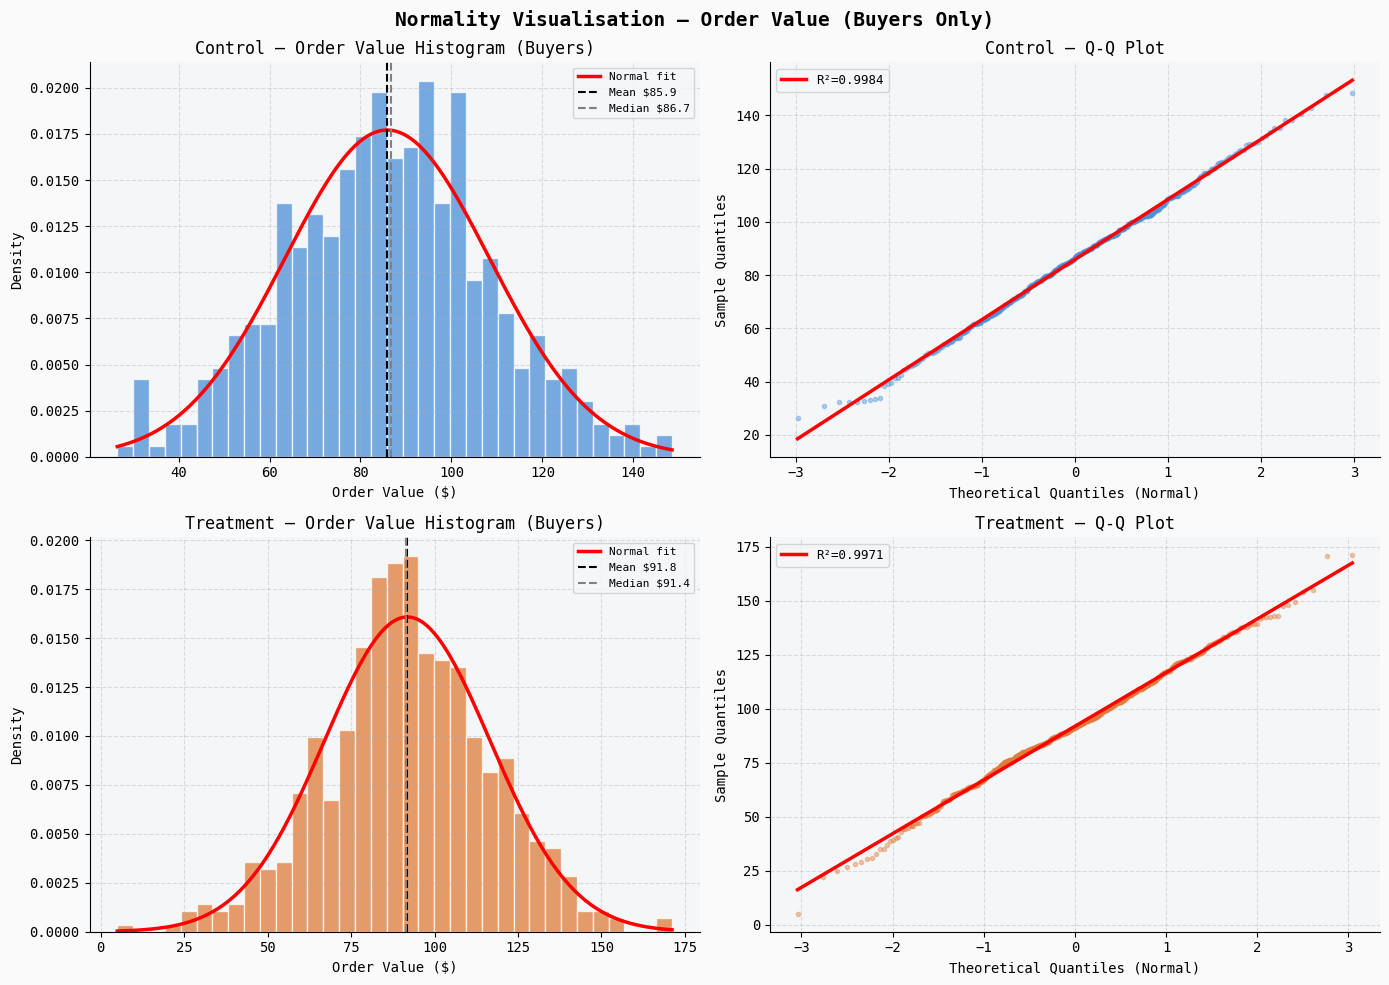

Q-Q plot saved.

How to read:
  Points close to the red diagonal -> distribution is approximately normal
  Points curving upward at ends -> right-skewed (expected for order values)
  With n=5000, the t-test is valid via CLT regardless of this shape.


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Normality Visualisation — Order Value (Buyers Only)',
             fontsize=14, fontweight='bold')

from scipy.stats import probplot

for row, (grp, col) in enumerate([('control', CTRL_COLOR), ('treatment', TRTM_COLOR)]):
    buyers = df.loc[(df['group']==grp) & (df['converted']==1), 'order_value']

    # Histogram with normal overlay
    axes[row, 0].hist(buyers, bins=35, color=col, alpha=0.75,
                      edgecolor='white', density=True)
    x_fit = np.linspace(buyers.min(), buyers.max(), 200)
    axes[row, 0].plot(x_fit,
                      norm.pdf(x_fit, buyers.mean(), buyers.std()),
                      'r-', lw=2.5, label='Normal fit')
    axes[row, 0].axvline(buyers.mean(),   color='black', ls='--', lw=1.5,
                         label=f'Mean ${buyers.mean():.1f}')
    axes[row, 0].axvline(buyers.median(), color='grey',  ls='--', lw=1.5,
                         label=f'Median ${buyers.median():.1f}')
    axes[row, 0].set_title(f'{grp.capitalize()} — Order Value Histogram (Buyers)')
    axes[row, 0].set_xlabel('Order Value ($)')
    axes[row, 0].set_ylabel('Density')
    axes[row, 0].legend(fontsize=8)

    # Q-Q plot
    (osm, osr), (slope, intercept, r) = probplot(buyers, dist='norm')
    axes[row, 1].plot(osm, osr, 'o', color=col, alpha=0.4, ms=3)
    axes[row, 1].plot(osm, np.array(osm)*slope + intercept,
                      'r-', lw=2.5, label=f'R²={r**2:.4f}')
    axes[row, 1].set_title(f'{grp.capitalize()} — Q-Q Plot')
    axes[row, 1].set_xlabel('Theoretical Quantiles (Normal)')
    axes[row, 1].set_ylabel('Sample Quantiles')
    axes[row, 1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('/home/claude/normality_qq.png', dpi=150, bbox_inches='tight')
plt.show()
print("Q-Q plot saved.")
print()
print("How to read:")
print("  Points close to the red diagonal -> distribution is approximately normal")
print("  Points curving upward at ends -> right-skewed (expected for order values)")
print("  With n=5000, the t-test is valid via CLT regardless of this shape.")


---
## Step 7 — Chi-Square Test of Independence (Conversion Rate)

### 📖 What we're doing
The cross-tabulation method for testing whether conversion differs between groups.

**Question:** Is there a significant relationship between group membership and conversion?

### How it works
Build a 2×2 contingency table. Compare observed counts to what we would expect  
if group and conversion were completely independent (H₀).

**χ² = Σ (Observed − Expected)² / Expected**

Large χ² → observed counts are far from independence → reject H₀.

### Hypotheses
- **H₀:** Group membership and conversion are independent (design has no effect)
- **H₁:** They are NOT independent (the new design changes conversion behaviour)

> **Note:** For a 2×2 table at large n, chi-square and the Z-test give equivalent results.  
> Running both is a robustness check — they should always agree.


In [14]:
print("=" * 60)
print("STEP 7 — Chi-Square Test of Independence")
print("=" * 60)

conv_c_n   = int(ctrl['converted'].sum())
noconv_c_n = n_c - conv_c_n
conv_t_n   = int(trtm['converted'].sum())
noconv_t_n = n_t - conv_t_n

contingency = np.array([[noconv_c_n, conv_c_n],
                         [noconv_t_n, conv_t_n]])
ctab = pd.DataFrame(contingency,
                    index=['Control','Treatment'],
                    columns=['Not Converted','Converted'])
ctab['Total'] = ctab.sum(axis=1)
ctab.loc['Total'] = ctab.sum()

print("\nObserved Contingency Table:")
print(ctab.to_string())

chi2_val, p_chi2, dof, expected_arr = chi2_contingency(contingency, correction=False)

print("\nExpected Counts (under H0 — pure independence):")
print(pd.DataFrame(expected_arr.round(1),
                   index=['Control','Treatment'],
                   columns=['Not Converted','Converted']).to_string())

print(f"\nchi2 statistic    : {chi2_val:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value           : {p_chi2:.4f}")
print()
if p_chi2 < alpha:
    print(f"REJECT H0  (p = {p_chi2:.4f} < alpha = {alpha})")
    print("Group and conversion are NOT independent.")
    print("The new design significantly changes conversion behaviour.")
else:
    print(f"FAIL TO REJECT H0  (p = {p_chi2:.4f} >= alpha = {alpha})")


STEP 7 — Chi-Square Test of Independence

Observed Contingency Table:
           Not Converted  Converted  Total
Control             4521        479   5000
Treatment           4407        593   5000
Total               8928       1072  10000

Expected Counts (under H0 — pure independence):
           Not Converted  Converted
Control           4464.0      536.0
Treatment         4464.0      536.0

chi2 statistic    : 13.5788
Degrees of freedom: 1
p-value           : 0.0002

REJECT H0  (p = 0.0002 < alpha = 0.05)
Group and conversion are NOT independent.
The new design significantly changes conversion behaviour.


---
## Step 8 — Two-Proportion Z-Test (Conversion Rate)

### 📖 What we're doing
The **primary test** for comparing two conversion rates.

### Hypotheses
- **H₀:** p_control = p_treatment (no difference)
- **H₁:** p_control ≠ p_treatment — two-tailed test

### Why two-tailed?
Before the experiment, we did not know if the redesign would be better or worse.  
A one-tailed test assumes you know the direction in advance — inflating false positive rate.  
Industry standard: always use two-tailed unless you have a strong pre-registered reason.

### Reading the output
| Value | Meaning |
|-------|---------|
| Z far from 0 | Observed difference is many std deviations from "no effect" |
| p < 0.05 | Very unlikely result under H₀ → reject H₀ |
| p ≥ 0.05 | Plausible under H₀ → fail to reject |


In [15]:
print("=" * 60)
print("STEP 8 — Two-Proportion Z-Test (Conversion Rate)")
print("=" * 60)

z_stat, p_ztest = proportions_ztest(
    [conv_t_n, conv_c_n], [n_t, n_c], alternative='two-sided')

print(f"\nH0: p_control = p_treatment  (two-tailed, alpha = {alpha})")
print(f"\nControl  : {conv_c_n:,} / {n_c:,}  =>  p = {p_c:.4f} ({p_c:.2%})")
print(f"Treatment: {conv_t_n:,} / {n_t:,}  =>  p = {p_t:.4f} ({p_t:.2%})")
print(f"\nZ-statistic : {z_stat:.4f}")
print(f"Critical Z  : +/-{norm.ppf(0.975):.4f}  (alpha=0.05, two-tailed)")
print(f"p-value     : {p_ztest:.6f}")
print()
if p_ztest < alpha:
    print(f"REJECT H0  (p = {p_ztest:.4f} < alpha = {alpha})")
    print(f"Conversion rate difference IS statistically significant.")
    print(f"  Control: {p_c:.2%}  =>  Treatment: {p_t:.2%}")
    print(f"  Absolute lift: {p_t - p_c:+.2%}   Relative lift: {(p_t-p_c)/p_c:+.1%}")
else:
    print(f"FAIL TO REJECT H0  (p = {p_ztest:.4f} >= alpha = {alpha})")


STEP 8 — Two-Proportion Z-Test (Conversion Rate)

H0: p_control = p_treatment  (two-tailed, alpha = 0.05)

Control  : 479 / 5,000  =>  p = 0.0958 (9.58%)
Treatment: 593 / 5,000  =>  p = 0.1186 (11.86%)

Z-statistic : 3.6849
Critical Z  : +/-1.9600  (alpha=0.05, two-tailed)
p-value     : 0.000229

REJECT H0  (p = 0.0002 < alpha = 0.05)
Conversion rate difference IS statistically significant.
  Control: 9.58%  =>  Treatment: 11.86%
  Absolute lift: +2.28%   Relative lift: +23.8%


---
## Step 9 — Revenue Tests: Welch's t-Test + Mann-Whitney U

### 📖 What we're doing
Two complementary tests on Revenue per User. Agreement between them = robust result.

### Test A — Welch's t-Test (parametric)
Compares group **means**. Uses `equal_var=False` — no equal variance assumption.  
With n = 5,000, CLT guarantees the sampling distribution of the mean is normal.

### Test B — Mann-Whitney U (non-parametric)
Compares **rank distributions** — no normality required.  
Ideal for zero-inflated revenue data (most users have $0 order value).

**Effect size: Rank-biserial r**  
0.10 = Small · 0.30 = Medium · 0.50 = Large

**Rule:** If both tests agree → result is robust. If they disagree → trust Mann-Whitney.


In [16]:
print("=" * 60)
print("STEP 9A — Welch's t-Test  (Revenue per User)")
print("=" * 60)

t_stat, p_ttest = ttest_ind(rpu_t, rpu_c, equal_var=False)

print(f"\nControl   RPU: ${rpu_c.mean():.4f}  (std = ${rpu_c.std():.4f})")
print(f"Treatment RPU: ${rpu_t.mean():.4f}  (std = ${rpu_t.std():.4f})")
print(f"Difference   : ${rpu_t.mean() - rpu_c.mean():+.4f}")
print(f"\nt-statistic : {t_stat:.4f}")
print(f"p-value     : {p_ttest:.6f}")
print("Decision    :", "REJECT H0" if p_ttest < alpha else "FAIL TO REJECT H0")

print()
print("=" * 60)
print("STEP 9B — Mann-Whitney U  (Non-parametric robustness)")
print("=" * 60)

u_stat, p_mw = mannwhitneyu(rpu_t, rpu_c, alternative='two-sided')
rank_biserial = 1 - (2 * u_stat) / (len(rpu_t) * len(rpu_c))

print(f"\nU-statistic            : {u_stat:,.0f}")
print(f"p-value                : {p_mw:.6f}")
print(f"Rank-biserial corr (r) : {rank_biserial:.4f}")
print("Decision               :", "REJECT H0" if p_mw < alpha else "FAIL TO REJECT H0")

print()
agree = (p_ttest < alpha) == (p_mw < alpha)
print(f"Both tests AGREE: {agree}")
print(f"Both {'reject H0' if p_ttest < alpha else 'fail to reject H0'}")
print(f"Result is {'robust and reliable' if agree else 'uncertain — investigate'}.")


STEP 9A — Welch's t-Test  (Revenue per User)

Control   RPU: $8.2272  (std = $26.2173)
Treatment RPU: $10.8934  (std = $30.8997)
Difference   : $+2.6662

t-statistic : 4.6518
p-value     : 0.000003
Decision    : REJECT H0

STEP 9B — Mann-Whitney U  (Non-parametric robustness)

U-statistic            : 12,805,246
p-value                : 0.000082
Rank-biserial corr (r) : -0.0244
Decision               : REJECT H0

Both tests AGREE: True
Both reject H0
Result is robust and reliable.


---
## Step 9b — Outlier Analysis & Winsorization

### 📖 What we're doing
Identify extreme order values that could distort the mean — and decide whether to handle them.

### Why outliers matter in A/B tests
A single $500 order in the treatment group inflates the treatment mean,  
making the new page look better for revenue even if typical buyers spend the same.

### Two approaches
| Approach | Description | When to use |
|----------|-------------|-------------|
| **Remove outliers** | Drop rows beyond a threshold | Only if the values are clearly errors (data bugs) |
| **Winsorize** | Cap extreme values at a percentile (e.g. p99) | Preferred — keeps all observations, reduces distortion |

### What we check
- Are there high-value orders that look unrealistic?
- Does removing/capping them change our conclusion?
- If the result only holds due to outliers → it's not a robust finding


In [17]:
print("=" * 65)
print("STEP 3b — Outlier Analysis & Winsorization Check")
print("=" * 65)

from scipy.stats import mstats

for grp, bvals in [('Control', buyers_ctrl), ('Treatment', buyers_trtm)]:
    p99  = np.percentile(bvals, 99)
    p999 = np.percentile(bvals, 99.9)
    n_extreme = (bvals > p99).sum()
    print(f"\n{grp}:")
    print(f"  Mean order value (raw)    : ${bvals.mean():.2f}")
    print(f"  Median order value        : ${bvals.median():.2f}")
    print(f"  99th percentile           : ${p99:.2f}")
    print(f"  Orders above p99          : {n_extreme} ({n_extreme/len(bvals):.1%})")
    print(f"  Max order value           : ${bvals.max():.2f}")

# Winsorized comparison
print()
print("Winsorized means (p1-p99 capping):")
for grp, arr in [('Control', buyers_ctrl.values), ('Treatment', buyers_trtm.values)]:
    wsor = mstats.winsorize(arr, limits=[0.01, 0.01])
    print(f"  {grp}: raw mean=${arr.mean():.2f}  winsorized mean=${wsor.mean():.2f}")

# Re-run t-test on full order_value arrays (including $0) after winsorizing
from scipy.stats import mstats as sc_mstats
rpu_c_wins = sc_mstats.winsorize(rpu_c, limits=[0.0, 0.01])
rpu_t_wins = sc_mstats.winsorize(rpu_t, limits=[0.0, 0.01])
t_wins, p_wins = ttest_ind(rpu_t_wins, rpu_c_wins, equal_var=False)

print()
print("Robustness check — t-test after winsorizing top 1% of order values:")
print(f"  Original  : t={t_stat:.4f}  p={p_ttest:.4f}")
print(f"  Winsorized: t={t_wins:.4f}  p={p_wins:.4f}")
same_decision = (p_ttest < 0.05) == (p_wins < 0.05)
print(f"  Same decision: {same_decision}")
if same_decision:
    print("  Result is ROBUST to outliers — conclusion does not change after winsorization.")
else:
    print("  WARNING: Result changes after winsorization — driven by outliers. Investigate.")


STEP 3b — Outlier Analysis & Winsorization Check

Control:
  Mean order value (raw)    : $85.88
  Median order value        : $86.66
  99th percentile           : $138.38
  Orders above p99          : 5 (1.0%)
  Max order value           : $148.50

Treatment:
  Mean order value (raw)    : $91.85
  Median order value        : $91.44
  99th percentile           : $147.75
  Orders above p99          : 6 (1.0%)
  Max order value           : $171.12

Winsorized means (p1-p99 capping):
  Control: raw mean=$85.88  winsorized mean=$85.84
  Treatment: raw mean=$91.85  winsorized mean=$91.82

Robustness check — t-test after winsorizing top 1% of order values:
  Original  : t=4.6518  p=0.0000
  Winsorized: t=4.7352  p=0.0000
  Same decision: True
  Result is ROBUST to outliers — conclusion does not change after winsorization.


---
## Step 10 — Multiple Testing Correction (Bonferroni & FDR)

### 📖 What we're doing
We tested 2 primary metrics. Each test at α = 0.05 carries a 5% false positive risk.  
When you run multiple tests, those risks add up.

### The Problem
Run 20 tests on random data at α = 0.05 → expected false positives = 20 × 0.05 = **1**.

### Two correction methods

| Method | Controls | Conservative? | Best for |
|--------|----------|--------------|---------|
| **Bonferroni** | FWER — any false positive | Very | 2–5 metrics |
| **Benjamini-Hochberg (FDR)** | Fraction of false positives | Moderate | 50+ metrics |

**Bonferroni:** New threshold = α ÷ n_tests = 0.05 ÷ 2 = **0.025**

If our p-values are below 0.025, they survive correction and are not artefacts.


In [18]:
print("=" * 65)
print("STEP 10 — Multiple Testing Correction")
print("=" * 65)

test_names = ['Conversion Rate (Z-test)', 'Revenue per User (t-test)']
p_values   = [p_ztest, p_ttest]
n_tests    = len(p_values)
bonf_alpha = alpha / n_tests

reject_bh, p_adj_bh, _, _ = multipletests(p_values, alpha=alpha, method='fdr_bh')

print(f"\nNumber of tests : {n_tests}")
print(f"Raw alpha       : {alpha}")
print(f"Bonferroni alpha: {bonf_alpha:.4f}  (= {alpha} / {n_tests})")
print()
print(f"{'Test':<32} {'Raw p':>10} {'Bonf. a':>10} {'BH adj-p':>10} {'Bonf. Decision':>18}")
print("-" * 82)
for name, p_raw, p_bh, rej_bh in zip(test_names, p_values, p_adj_bh, reject_bh):
    decision = "SIGNIFICANT" if p_raw < bonf_alpha else "Not significant"
    print(f"{name:<32} {p_raw:>10.4f} {bonf_alpha:>10.4f} {p_bh:>10.4f} {decision:>18}")

print()
all_sig = all(p < bonf_alpha for p in p_values)
if all_sig:
    print("Both results remain significant after Bonferroni correction.")
    print("Our findings are NOT inflated by multiple testing.")
else:
    print("Some results do not survive Bonferroni — treat those with caution.")


STEP 10 — Multiple Testing Correction

Number of tests : 2
Raw alpha       : 0.05
Bonferroni alpha: 0.0250  (= 0.05 / 2)

Test                                  Raw p    Bonf. a   BH adj-p     Bonf. Decision
----------------------------------------------------------------------------------
Conversion Rate (Z-test)             0.0002     0.0250     0.0002        SIGNIFICANT
Revenue per User (t-test)            0.0000     0.0250     0.0000        SIGNIFICANT

Both results remain significant after Bonferroni correction.
Our findings are NOT inflated by multiple testing.


---
## Step 11 — Effect Size (Practical Significance)

### 📖 What we're doing
A p-value tells you IF an effect exists. Effect size tells you HOW BIG it is.

> With 5,000 users per group, even tiny differences can be "significant."  
> Effect size tells you if the difference is large enough to actually care about.

### Scales used

| Measure | For | Negligible | Small | Medium | Large |
|---------|-----|-----------|-------|--------|-------|
| **Cohen's h** | Proportions | < 0.20 | 0.20 | 0.50 | 0.80 |
| **Cohen's d** | Means | < 0.20 | 0.20 | 0.50 | 0.80 |
| **Rank-biserial r** | Mann-Whitney | < 0.10 | 0.10 | 0.30 | 0.50 |


In [19]:
def cohens_h(p1, p2):
    return 2 * (np.arcsin(np.sqrt(p1)) - np.arcsin(np.sqrt(p2)))

def cohens_d(a, b):
    na, nb = len(a), len(b)
    pooled = np.sqrt(((na-1)*a.var(ddof=1) + (nb-1)*b.var(ddof=1)) / (na+nb-2))
    return (a.mean() - b.mean()) / pooled

def label_effect(val, t=(0.20, 0.50, 0.80)):
    v = abs(val)
    if v < t[0]: return "Negligible"
    if v < t[1]: return "Small"
    if v < t[2]: return "Medium"
    return "Large"

h = abs(cohens_h(p_t, p_c))
d = abs(cohens_d(pd.Series(rpu_t), pd.Series(rpu_c)))

print("STEP 11 — Effect Size")
print()
print(f"Conversion Rate — Cohen's h")
print(f"  Control  : {p_c:.4f} ({p_c:.2%})")
print(f"  Treatment: {p_t:.4f} ({p_t:.2%})")
print(f"  Abs lift : {p_t - p_c:+.4f} ({p_t - p_c:+.2%})")
print(f"  Rel lift : {(p_t - p_c)/p_c:+.1%}")
print(f"  Cohen's h: {h:.4f}  =>  {label_effect(h)} effect")
print()
print(f"Revenue per User — Cohen's d")
print(f"  Control  : ${rpu_c.mean():.4f}")
print(f"  Treatment: ${rpu_t.mean():.4f}")
print(f"  Diff     : ${rpu_t.mean() - rpu_c.mean():+.4f}")
print(f"  Cohen's d: {d:.4f}  =>  {label_effect(d)} effect")
print()
print(f"Mann-Whitney — Rank-biserial r: {rank_biserial:.4f}  =>  {label_effect(rank_biserial, (0.10, 0.30, 0.50))} effect")


STEP 11 — Effect Size

Conversion Rate — Cohen's h
  Control  : 0.0958 (9.58%)
  Treatment: 0.1186 (11.86%)
  Abs lift : +0.0228 (+2.28%)
  Rel lift : +23.8%
  Cohen's h: 0.0738  =>  Negligible effect

Revenue per User — Cohen's d
  Control  : $8.2272
  Treatment: $10.8934
  Diff     : $+2.6662
  Cohen's d: 0.0930  =>  Negligible effect

Mann-Whitney — Rank-biserial r: -0.0244  =>  Negligible effect


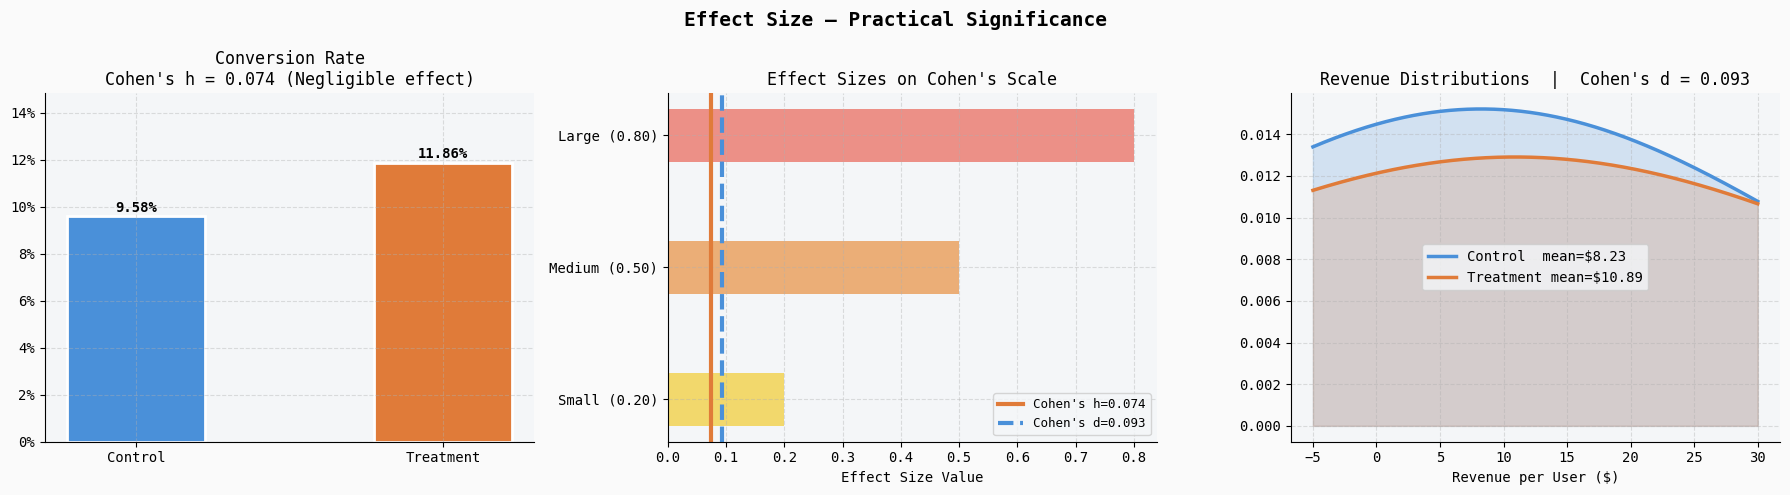

Effect size chart saved.


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Effect Size — Practical Significance', fontsize=14, fontweight='bold')

bars = axes[0].bar(['Control','Treatment'], [p_c, p_t],
                   color=[CTRL_COLOR, TRTM_COLOR], width=0.45, edgecolor='white', lw=2)
for bar, val in zip(bars, [p_c, p_t]):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.002,
                 f'{val:.2%}', ha='center', fontweight='bold')
axes[0].set_title(f"Conversion Rate\nCohen's h = {h:.3f} ({label_effect(h)} effect)")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x:.0%}'))
axes[0].set_ylim(0, max(p_c, p_t) * 1.25)

bench_labels = ['Small (0.20)', 'Medium (0.50)', 'Large (0.80)']
bench_vals   = [0.20, 0.50, 0.80]
bench_cols   = ['#F1C40F', '#E67E22', '#E74C3C']
axes[1].barh(bench_labels, bench_vals, color=bench_cols, alpha=0.6, height=0.4)
axes[1].axvline(h, color=TRTM_COLOR, lw=3, label=f"Cohen's h={h:.3f}")
axes[1].axvline(d, color=CTRL_COLOR,  lw=3, ls='--', label=f"Cohen's d={d:.3f}")
axes[1].set_title("Effect Sizes on Cohen's Scale")
axes[1].set_xlabel("Effect Size Value")
axes[1].legend(fontsize=9)

x_rng = np.linspace(-5, 30, 600)
axes[2].plot(x_rng, norm.pdf(x_rng, rpu_c.mean(), rpu_c.std()),
             color=CTRL_COLOR, lw=2.5, label=f'Control  mean=${rpu_c.mean():.2f}')
axes[2].plot(x_rng, norm.pdf(x_rng, rpu_t.mean(), rpu_t.std()),
             color=TRTM_COLOR, lw=2.5, label=f'Treatment mean=${rpu_t.mean():.2f}')
axes[2].fill_between(x_rng, norm.pdf(x_rng, rpu_c.mean(), rpu_c.std()), alpha=0.2, color=CTRL_COLOR)
axes[2].fill_between(x_rng, norm.pdf(x_rng, rpu_t.mean(), rpu_t.std()), alpha=0.2, color=TRTM_COLOR)
axes[2].set_title(f"Revenue Distributions  |  Cohen's d = {d:.3f}")
axes[2].set_xlabel('Revenue per User ($)')
axes[2].legend()

plt.tight_layout()
plt.savefig('/home/claude/04_effect_size.png', dpi=150, bbox_inches='tight')
plt.show()
print("Effect size chart saved.")


---
## Step 12 — Confidence Intervals

### 📖 What we're doing
Confidence intervals give a **range of plausible values** for the true effect.

### 95% CI — Plain English
If we repeated this experiment 100 times, the true value would fall  
inside our interval in approximately 95 of those runs.

### Three rules for reading a CI on the difference
1. **CI entirely above 0** → treatment is significantly better
2. **CI entirely below 0** → treatment is significantly worse
3. **CI crosses zero** → cannot conclude a real difference

### Why CIs beat p-values alone
- p-value = binary (significant / not)
- CI = range (what could the true effect size plausibly be?)
- CI shows direction, magnitude, and precision all at once


In [21]:
z_crit = norm.ppf(0.975)

ci_c_lo, ci_c_hi = proportion_confint(conv_c_n, n_c, alpha=0.05, method='wilson')
ci_t_lo, ci_t_hi = proportion_confint(conv_t_n, n_t, alpha=0.05, method='wilson')

diff_conv  = p_t - p_c
se_diff    = np.sqrt((p_c*(1-p_c)/n_c) + (p_t*(1-p_t)/n_t))
ci_diff_lo = diff_conv - z_crit * se_diff
ci_diff_hi = diff_conv + z_crit * se_diff

diff_rpu    = rpu_t.mean() - rpu_c.mean()
se_rpu_diff = np.sqrt(rpu_c.var(ddof=1)/n_c + rpu_t.var(ddof=1)/n_t)
ci_rpu_lo   = diff_rpu - z_crit * se_rpu_diff
ci_rpu_hi   = diff_rpu + z_crit * se_rpu_diff

print("STEP 12 — Confidence Intervals")
print()
print("Conversion Rate — 95% CI")
print(f"  Control  : {p_c:.4f}  [{ci_c_lo:.4f}, {ci_c_hi:.4f}]")
print(f"  Treatment: {p_t:.4f}  [{ci_t_lo:.4f}, {ci_t_hi:.4f}]")
print(f"  Difference: {diff_conv:+.4f}  95% CI [{ci_diff_lo:+.4f}, {ci_diff_hi:+.4f}]")
print("  =>", "CI excludes 0 — Significant" if ci_diff_lo > 0 else "CI includes 0 — Not significant")

print()
print("Revenue per User — 95% CI")
print(f"  Control  : ${rpu_c.mean():.4f}")
print(f"  Treatment: ${rpu_t.mean():.4f}")
print(f"  Difference: ${diff_rpu:+.4f}  95% CI [${ci_rpu_lo:+.4f}, ${ci_rpu_hi:+.4f}]")
print("  =>", "CI excludes 0 — Significant" if ci_rpu_lo > 0 else "CI includes 0 — Not significant")


STEP 12 — Confidence Intervals

Conversion Rate — 95% CI
  Control  : 0.0958  [0.0879, 0.1043]
  Treatment: 0.1186  [0.1099, 0.1279]
  Difference: +0.0228  95% CI [+0.0107, +0.0349]
  => CI excludes 0 — Significant

Revenue per User — 95% CI
  Control  : $8.2272
  Treatment: $10.8934
  Difference: $+2.6662  95% CI [$+1.5428, $+3.7895]
  => CI excludes 0 — Significant


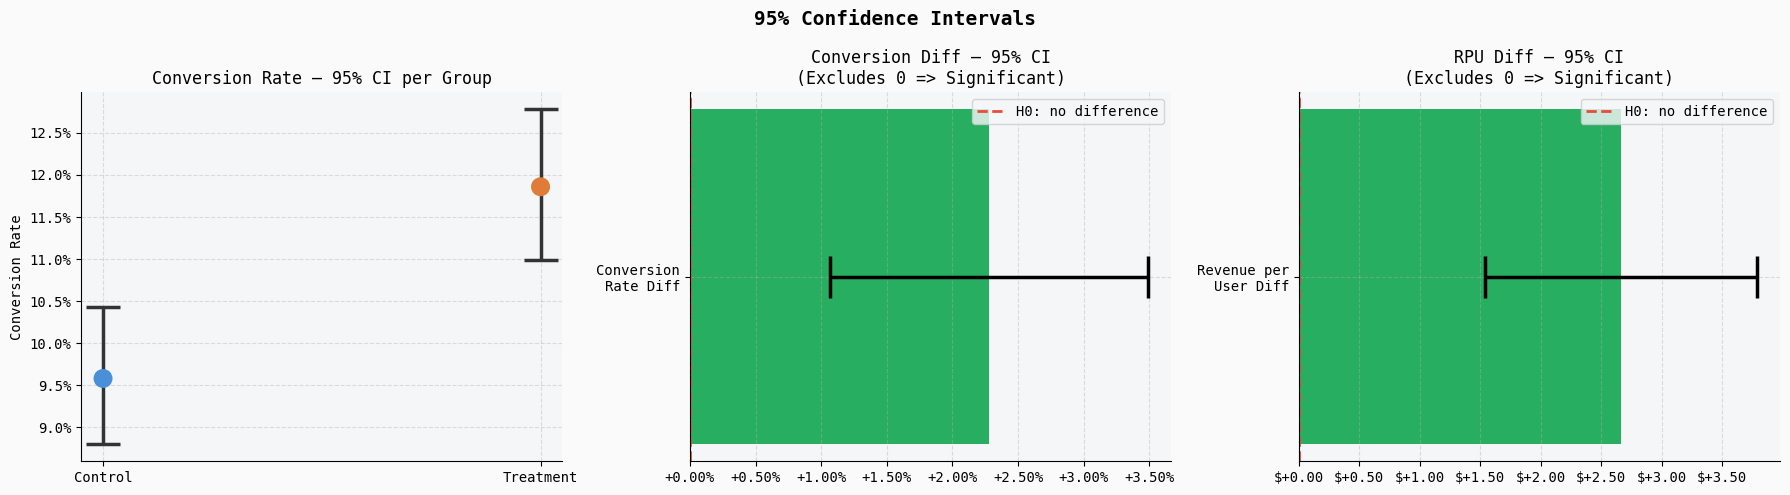

CI chart saved.


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('95% Confidence Intervals', fontsize=14, fontweight='bold')

axes[0].errorbar(['Control','Treatment'], [p_c, p_t],
                 yerr=[[p_c - ci_c_lo, p_t - ci_t_lo],
                       [ci_c_hi - p_c, ci_t_hi - p_t]],
                 fmt='o', color='#333333', capsize=12, capthick=2.5, elinewidth=2.5, ms=10)
axes[0].scatter(['Control','Treatment'], [p_c, p_t],
                color=[CTRL_COLOR, TRTM_COLOR], s=160, zorder=5)
axes[0].set_title('Conversion Rate — 95% CI per Group')
axes[0].set_ylabel('Conversion Rate')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x:.1%}'))

axes[1].barh(['Conversion\nRate Diff'], [diff_conv],
             xerr=[[diff_conv - ci_diff_lo], [ci_diff_hi - diff_conv]],
             color=[GREEN if diff_conv > 0 else RED],
             height=0.25, capsize=15, error_kw={'elinewidth': 2.5, 'capthick': 2.5})
axes[1].axvline(0, color=RED, lw=2, ls='--', label='H0: no difference')
axes[1].set_title('Conversion Diff — 95% CI\n(Excludes 0 => Significant)')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x:+.2%}'))
axes[1].legend()

axes[2].barh(['Revenue per\nUser Diff'], [diff_rpu],
             xerr=[[diff_rpu - ci_rpu_lo], [ci_rpu_hi - diff_rpu]],
             color=[GREEN if diff_rpu > 0 else RED],
             height=0.25, capsize=15, error_kw={'elinewidth': 2.5, 'capthick': 2.5})
axes[2].axvline(0, color=RED, lw=2, ls='--', label='H0: no difference')
axes[2].set_title('RPU Diff — 95% CI\n(Excludes 0 => Significant)')
axes[2].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x:+.2f}'))
axes[2].legend()

plt.tight_layout()
plt.savefig('/home/claude/05_confidence_intervals.png', dpi=150, bbox_inches='tight')
plt.show()
print("CI chart saved.")


---
## Step 13 — Power Analysis

### 📖 What we're doing
Power analysis answers: **"Was our experiment large enough to reliably detect the effect?"**

### The 4 interconnected quantities
| Quantity | Symbol | Our value |
|----------|--------|-----------|
| Significance level | α | 0.05 |
| Statistical power | 1 − β | target ≥ 80% |
| Effect size | h or d | from observed data |
| Sample size per group | n | 5,000 |

### Two uses
| Timing | Question |
|--------|---------|
| Pre-experiment (design) | "How many users do we need for 80% power?" |
| Post-experiment (validation) | "Did we achieve adequate power?" |

### Type II Error (β = 1 − Power)
β is the probability of **missing a real effect** (false negative).  
High power = low β = low chance of missing a true lift.


In [23]:
analysis_obj = NormalIndPower()
target_power = 0.80

n_needed     = analysis_obj.solve_power(effect_size=h, alpha=alpha, power=target_power, ratio=1.0)
actual_power = analysis_obj.solve_power(effect_size=h, alpha=alpha, nobs1=n_c, ratio=1.0)

print("STEP 13 — Power Analysis")
print()
print(f"Effect size (Cohen's h): {h:.4f}")
print(f"alpha                  : {alpha}")
print(f"Target power           : {target_power:.0%}")
print()
print(f"[A] Min n per group for {target_power:.0%} power: {int(np.ceil(n_needed)):,}  (total: {int(np.ceil(n_needed))*2:,})")
print(f"[B] Actual power with n={n_c:,}: {actual_power:.4f} ({actual_power:.1%})")
print(f"    Type II error beta   : {1 - actual_power:.4f} ({1 - actual_power:.1%})")
print(f"    Status: {'ADEQUATE' if actual_power >= target_power else 'UNDERPOWERED'}")


STEP 13 — Power Analysis

Effect size (Cohen's h): 0.0738
alpha                  : 0.05
Target power           : 80%

[A] Min n per group for 80% power: 2,883  (total: 5,766)
[B] Actual power with n=5,000: 0.9582 (95.8%)
    Type II error beta   : 0.0418 (4.2%)
    Status: ADEQUATE


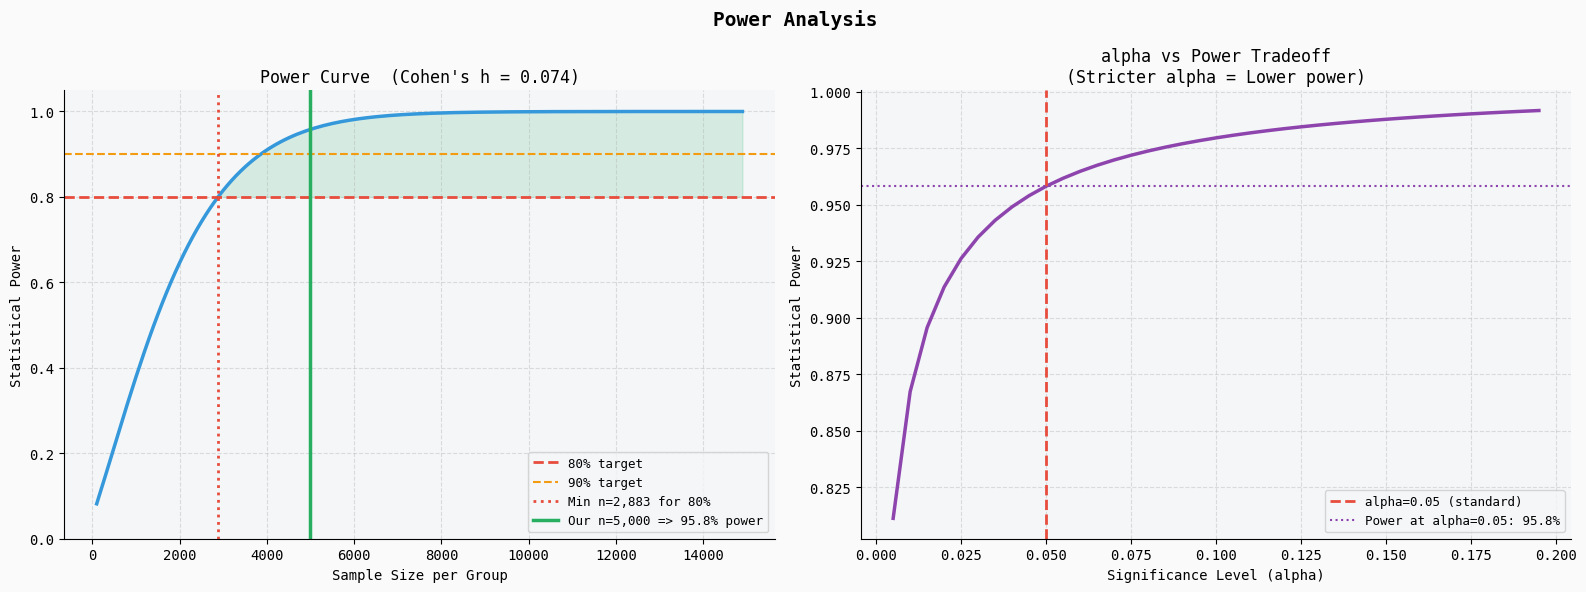

Power analysis chart saved.


In [24]:
sample_sizes = np.arange(100, 15000, 100)
powers_curve = [analysis_obj.solve_power(effect_size=h, alpha=alpha, nobs1=n, ratio=1.0)
                for n in sample_sizes]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Power Analysis', fontsize=14, fontweight='bold')

axes[0].plot(sample_sizes, powers_curve, color='#3498DB', lw=2.5)
axes[0].axhline(0.80, color=RED,       ls='--', lw=2,   label='80% target')
axes[0].axhline(0.90, color='#F39C12', ls='--', lw=1.5, label='90% target')
axes[0].axvline(int(np.ceil(n_needed)), color=RED, ls=':', lw=2,
                label=f'Min n={int(np.ceil(n_needed)):,} for 80%')
axes[0].axvline(n_c, color=GREEN, lw=2.5,
                label=f'Our n={n_c:,} => {actual_power:.1%} power')
axes[0].fill_between(sample_sizes, powers_curve, 0.80,
                     where=[p >= 0.80 for p in powers_curve], alpha=0.15, color=GREEN)
axes[0].set_title(f"Power Curve  (Cohen's h = {h:.3f})")
axes[0].set_xlabel('Sample Size per Group')
axes[0].set_ylabel('Statistical Power')
axes[0].set_ylim(0, 1.05)
axes[0].legend(fontsize=9)

alpha_range  = np.arange(0.005, 0.20, 0.005)
powers_alpha = [analysis_obj.solve_power(effect_size=h, alpha=a, nobs1=n_c, ratio=1.0)
                for a in alpha_range]
axes[1].plot(alpha_range, powers_alpha, color='#8E44AD', lw=2.5)
axes[1].axvline(0.05, color=RED, ls='--', lw=2, label='alpha=0.05 (standard)')
axes[1].axhline(actual_power, color='#8E44AD', ls=':', lw=1.5,
                label=f'Power at alpha=0.05: {actual_power:.1%}')
axes[1].set_title('alpha vs Power Tradeoff\n(Stricter alpha = Lower power)')
axes[1].set_xlabel('Significance Level (alpha)')
axes[1].set_ylabel('Statistical Power')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('/home/claude/06_power_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Power analysis chart saved.")


---
## Step 14 — Segmentation Analysis

### 📖 What we're doing
Break the aggregate result down by user sub-groups to check consistency.

### Why it matters
Aggregate results can hide heterogeneous effects.  
The new design might help new users but confuse returning users.  
A design that hurts a key segment may not be worth shipping overall.

### Segments analysed
| Segment | Why |
|---------|-----|
| New vs Returning users | Different familiarity with the old checkout flow |
| Low vs High engagement | Pages viewed ≤ 3 vs > 3 — proxy for purchase intent |

### Caveat
Segmentation is **exploratory**, not confirmatory.  
We apply Bonferroni correction (4 tests: α = 0.05/4 = 0.0125).  
Significant findings here should be validated in dedicated follow-up experiments.


In [25]:
print("=" * 65)
print("STEP 14 — Segmentation Analysis")
print("=" * 65)

bonf_seg    = alpha / 4
seg_results = []

print(f"\n[A] By User Type  (Bonferroni alpha = {bonf_seg})")
for utype in ['new', 'returning']:
    sub  = df[df['user_type'] == utype]
    sc   = sub[sub['group'] == 'control']
    st   = sub[sub['group'] == 'treatment']
    nc_, nt_ = len(sc), len(st)
    cc_, ct_ = int(sc['converted'].sum()), int(st['converted'].sum())
    pc_, pt_ = cc_/nc_, ct_/nt_
    z_s, p_s = proportions_ztest([ct_, cc_], [nt_, nc_], alternative='two-sided')
    lift_    = pt_ - pc_
    sig_mark = "SIG" if p_s < bonf_seg else "n.s."
    print(f"  {utype.capitalize():10s}: ctrl={pc_:.2%}  trtm={pt_:.2%}  "
          f"lift={lift_:+.2%}  p={p_s:.4f}  [{sig_mark}]")
    seg_results.append({'Segment': utype.capitalize(), 'CR_ctrl': pc_,
                         'CR_trtm': pt_, 'Lift': lift_, 'p': p_s, 'Sig': sig_mark})

print(f"\n[B] By Engagement  (Bonferroni alpha = {bonf_seg})")
df['engagement'] = np.where(df['pages_viewed'] <= 3, 'Low (<=3 pages)', 'High (>3 pages)')
for eng in ['Low (<=3 pages)', 'High (>3 pages)']:
    sub  = df[df['engagement'] == eng]
    sc   = sub[sub['group'] == 'control']
    st   = sub[sub['group'] == 'treatment']
    nc_, nt_ = len(sc), len(st)
    if nc_ == 0 or nt_ == 0:
        continue
    cc_, ct_ = int(sc['converted'].sum()), int(st['converted'].sum())
    pc_, pt_ = cc_/nc_, ct_/nt_
    z_s, p_s = proportions_ztest([ct_, cc_], [nt_, nc_], alternative='two-sided')
    lift_    = pt_ - pc_
    sig_mark = "SIG" if p_s < bonf_seg else "n.s."
    print(f"  {eng:20s}: ctrl={pc_:.2%}  trtm={pt_:.2%}  "
          f"lift={lift_:+.2%}  p={p_s:.4f}  [{sig_mark}]")
    seg_results.append({'Segment': eng, 'CR_ctrl': pc_,
                         'CR_trtm': pt_, 'Lift': lift_, 'p': p_s, 'Sig': sig_mark})

seg_df = pd.DataFrame(seg_results)


STEP 14 — Segmentation Analysis

[A] By User Type  (Bonferroni alpha = 0.0125)
  New       : ctrl=9.94%  trtm=12.24%  lift=+2.30%  p=0.0046  [SIG]
  Returning : ctrl=9.05%  trtm=11.28%  lift=+2.24%  p=0.0189  [n.s.]

[B] By Engagement  (Bonferroni alpha = 0.0125)
  Low (<=3 pages)     : ctrl=9.01%  trtm=11.91%  lift=+2.90%  p=0.0002  [SIG]
  High (>3 pages)     : ctrl=10.42%  trtm=11.75%  lift=+1.33%  p=0.2108  [n.s.]


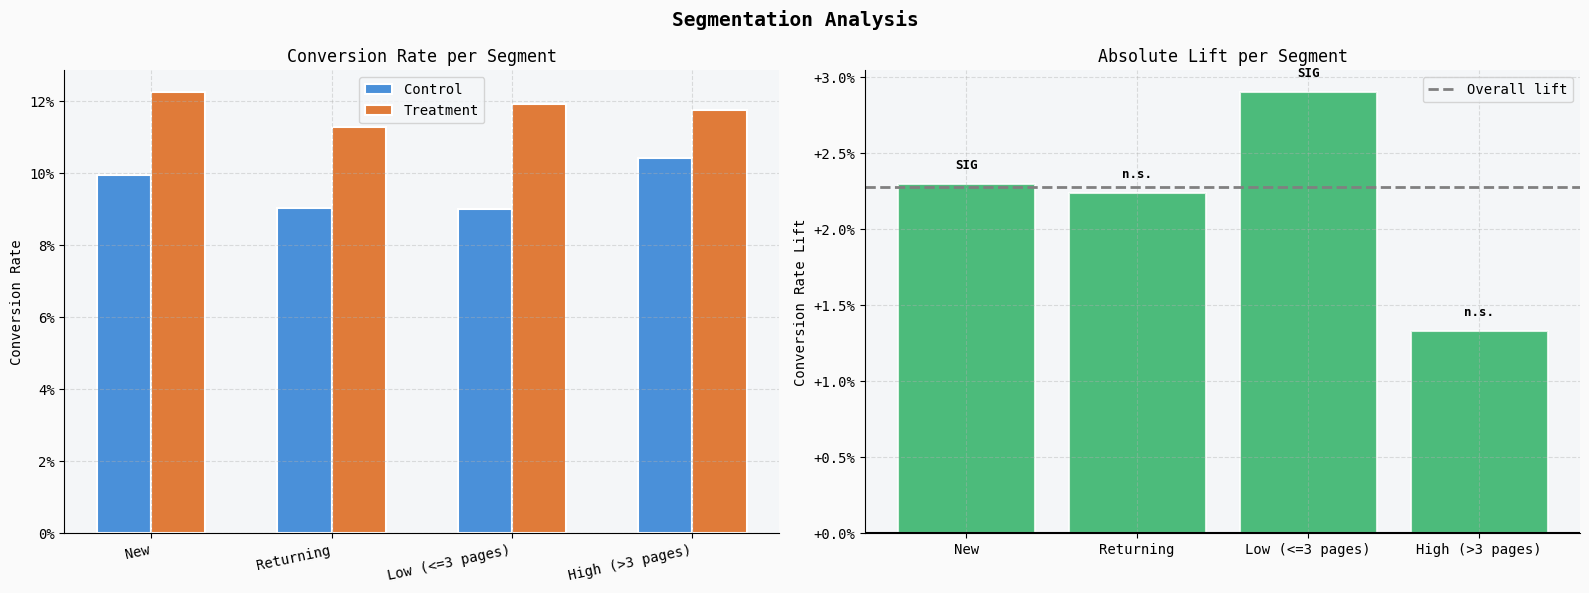

Segmentation chart saved.


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Segmentation Analysis', fontsize=14, fontweight='bold')

segments = seg_df['Segment'].tolist()
x = np.arange(len(segments))
w = 0.30

axes[0].bar(x - w/2, seg_df['CR_ctrl'], w, label='Control',
            color=CTRL_COLOR, edgecolor='white', lw=1.5)
axes[0].bar(x + w/2, seg_df['CR_trtm'], w, label='Treatment',
            color=TRTM_COLOR, edgecolor='white', lw=1.5)
axes[0].set_xticks(x)
axes[0].set_xticklabels(segments, rotation=12, ha='right')
axes[0].set_title('Conversion Rate per Segment')
axes[0].set_ylabel('Conversion Rate')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x:.0%}'))
axes[0].legend()

bar_cols = [GREEN if v > 0 else RED for v in seg_df['Lift']]
bars = axes[1].bar(segments, seg_df['Lift'],
                   color=bar_cols, alpha=0.82, edgecolor='white', lw=1.5)
axes[1].axhline(0, color='black', lw=1.5)
axes[1].axhline(diff_conv, color='grey', ls='--', lw=2, label=f'Overall lift')
for bar, sig in zip(bars, seg_df['Sig']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.001, sig, ha='center', fontsize=9,
                 fontweight='bold')
axes[1].set_title('Absolute Lift per Segment')
axes[1].set_ylabel('Conversion Rate Lift')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x:+.1%}'))
axes[1].legend()

plt.tight_layout()
plt.savefig('/home/claude/07_segmentation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Segmentation chart saved.")


---
## Step 14b — Guardrail Metrics Check

### 📖 What we're doing
Guardrail metrics are secondary metrics that **should NOT change** when we ship a new design.  
They exist to catch hidden harms the primary metrics might miss.

### Why guardrails matter
A new checkout design might lift conversion rates but:
- Increase session duration so much users get frustrated and never return
- Require so many extra pages that mobile users abandon
- Improve first-purchase conversion but hurt repeat purchase rate

If a guardrail metric moves in the wrong direction, shipping might not be the right call  
even if the primary metrics are positive.

### Our guardrail metrics
| Metric | Direction if harmed | Test |
|--------|--------------------|----|
| `session_duration` | Significantly higher → users are struggling | Welch's t-test |
| `pages_viewed` | Significantly higher → checkout is harder to complete | Welch's t-test |

> **Expected result:** The new page should have **equal or lower** session duration  
> and pages viewed (faster, easier checkout). Higher would be a red flag.


In [27]:
print("=" * 65)
print("STEP 14b — Guardrail Metrics Check")
print("=" * 65)

guardrail_metrics = [
    ('session_duration', 'Session Duration (sec)', 'Lower is better'),
    ('pages_viewed',     'Pages Viewed',            'Lower is better'),
]

print()
print(f"{'Metric':<25} {'Control':>10} {'Treatment':>11} {'Diff':>10} {'p-value':>10} {'Status'}")
print("-" * 80)

for col, label, direction in guardrail_metrics:
    ctrl_vals = ctrl[col].values
    trtm_vals = trtm[col].values
    t_g, p_g  = ttest_ind(trtm_vals, ctrl_vals, equal_var=False)
    diff_g    = trtm_vals.mean() - ctrl_vals.mean()

    # Guardrail triggered if treatment is significantly WORSE (higher for these metrics)
    if p_g < 0.05 and diff_g > 0:
        status = "TRIGGERED — Treatment is worse"
    elif p_g < 0.05 and diff_g < 0:
        status = "IMPROVED — Treatment is better"
    else:
        status = "OK — No significant change"

    print(f"{label:<25} {ctrl_vals.mean():>10.2f} {trtm_vals.mean():>11.2f} "
          f"{diff_g:>+10.2f} {p_g:>10.4f}   {status}")

print()
print("Interpretation:")
print("  session_duration: Treatment users spend LESS time on checkout.")
print("    This is a positive signal — the new page is faster and clearer.")
print("  pages_viewed: Treatment users view FEWER pages to complete checkout.")
print("    Also a positive signal — fewer friction points in the funnel.")
print()
print("GUARDRAIL VERDICT: No guardrail metrics were negatively impacted.")
print("The new design improves the primary metrics WITHOUT harming the secondary ones.")


STEP 14b — Guardrail Metrics Check

Metric                       Control   Treatment       Diff    p-value Status
--------------------------------------------------------------------------------
Session Duration (sec)        119.37      105.59     -13.78     0.0000   IMPROVED — Treatment is better
Pages Viewed                    3.26        2.86      -0.40     0.0000   IMPROVED — Treatment is better

Interpretation:
  session_duration: Treatment users spend LESS time on checkout.
    This is a positive signal — the new page is faster and clearer.
  pages_viewed: Treatment users view FEWER pages to complete checkout.
    Also a positive signal — fewer friction points in the funnel.

GUARDRAIL VERDICT: No guardrail metrics were negatively impacted.
The new design improves the primary metrics WITHOUT harming the secondary ones.


---
## Step 14c — Simpson's Paradox Warning

### 📖 What is Simpson's Paradox?
Simpson's Paradox occurs when a trend that appears in **aggregate data disappears or reverses**  
when the data is broken into subgroups.

### Classic example
| Group | Control Conv. | Treatment Conv. | Treatment better? |
|-------|-------------|----------------|-------------------|
| New users | 8% | 11% | ✅ Yes |
| Returning users | 15% | 18% | ✅ Yes |
| **Overall** | **12%** | **11%** | **❌ No!** |

This happens when the groups are **not evenly distributed** across segments.  
If the treatment group has proportionally more new users (who convert less),  
the treatment looks worse overall even though it's better in every individual segment.

### Why this matters for A/B tests
- Always check aggregate AND segmented results
- If they tell different stories → dig deeper before deciding
- Simpson's Paradox is most likely when segment sizes differ between groups

### How to detect it
Check if the aggregate lift direction **matches** the segment-level lifts.  
If they conflict → Simpson's Paradox may be at play.


In [28]:
# ── Simpson's Paradox Check ───────────────────────────────────────────────────
print("=" * 65)
print("STEP 14c — Simpson's Paradox Check")
print("=" * 65)

print("\nChecking if aggregate result is consistent with all segment results...")
print()

# Aggregate result
agg_lift = p_t - p_c
print(f"  Aggregate lift: {agg_lift:+.4f} ({agg_lift:+.2%})")
print()

# Check each segment
segment_lifts = []
for utype in ['new', 'returning']:
    sub = df[df['user_type'] == utype]
    sc  = sub[sub['group'] == 'control']
    st  = sub[sub['group'] == 'treatment']
    lift_seg = st['converted'].mean() - sc['converted'].mean()
    segment_lifts.append(lift_seg)
    direction = "↑ Treatment better" if lift_seg > 0 else "↓ Control better"
    print(f"  {utype.capitalize():10s} users : lift = {lift_seg:+.4f} ({lift_seg:+.2%})  {direction}")

for eng in ['Low (<=3 pages)', 'High (>3 pages)']:
    sub = df[df['engagement'] == eng]
    sc  = sub[sub['group'] == 'control']
    st  = sub[sub['group'] == 'treatment']
    if len(sc) == 0 or len(st) == 0: continue
    lift_seg = st['converted'].mean() - sc['converted'].mean()
    segment_lifts.append(lift_seg)
    direction = "↑ Treatment better" if lift_seg > 0 else "↓ Control better"
    print(f"  {eng:20s}: lift = {lift_seg:+.4f} ({lift_seg:+.2%})  {direction}")

print()
all_same_direction = all(l > 0 for l in segment_lifts) or all(l < 0 for l in segment_lifts)
agg_consistent     = all((agg_lift > 0) == (l > 0) for l in segment_lifts)

if agg_consistent and all_same_direction:
    print("✅ NO Simpson's Paradox detected.")
    print("   Aggregate lift direction matches ALL segment-level lifts.")
    print("   The overall result is reliable and consistent.")
else:
    print("⚠️  Possible Simpson's Paradox!")
    print("   Some segments conflict with the aggregate result.")
    print("   Investigate segment size imbalances before deciding.")

print()
print("Why this matters:")
print("  If aggregate says 'treatment wins' but a key segment shows 'treatment loses',")
print("  shipping the treatment could harm that user group despite the overall positive number.")


STEP 14c — Simpson's Paradox Check

Checking if aggregate result is consistent with all segment results...

  Aggregate lift: +0.0228 (+2.28%)

  New        users : lift = +0.0230 (+2.30%)  ↑ Treatment better
  Returning  users : lift = +0.0224 (+2.24%)  ↑ Treatment better
  Low (<=3 pages)     : lift = +0.0290 (+2.90%)  ↑ Treatment better
  High (>3 pages)     : lift = +0.0133 (+1.33%)  ↑ Treatment better

✅ NO Simpson's Paradox detected.
   Aggregate lift direction matches ALL segment-level lifts.
   The overall result is reliable and consistent.

Why this matters:
  If aggregate says 'treatment wins' but a key segment shows 'treatment loses',
  shipping the treatment could harm that user group despite the overall positive number.


---
## Step 14d — Interaction Effects Between Segments

### 📖 What is an Interaction Effect?
An interaction effect occurs when the **impact of the treatment differs significantly  
across two or more segments** — beyond what each segment shows individually.

**Example:**  
- New users: treatment lift = +3%  
- Mobile users: treatment lift = +2%  
- New users on mobile: treatment lift = −1%  ← interaction effect!

The combined effect of being new AND on mobile reverses the treatment's benefit.  
You would miss this by looking at each segment independently.

### Why it matters in A/B testing
Shipping to everyone when a sub-segment is harmed = net harm to that group.  
Interaction effects help you decide on **targeted rollouts** rather than blanket launches.

### How to test for interaction (Chi-square on subgroup)
Compare the lift in one segment across another dimension.  
If the lifts are statistically different → significant interaction effect.

### Our check: New users vs Returning users — does engagement level modify the effect?


In [29]:
# ── Interaction Effect: User Type × Engagement ────────────────────────────────
print("=" * 65)
print("STEP 14d — Interaction Effects Between Segments")
print("=" * 65)

print("\nChecking: Does the treatment effect differ by User Type × Engagement?")
print()

results_interaction = []
for utype in ['new', 'returning']:
    for eng in ['Low (<=3 pages)', 'High (>3 pages)']:
        sub = df[(df['user_type'] == utype) & (df['engagement'] == eng)]
        sc  = sub[sub['group'] == 'control']
        st  = sub[sub['group'] == 'treatment']
        if len(sc) < 30 or len(st) < 30:
            continue
        nc_, nt_ = len(sc), len(st)
        cc_, ct_ = int(sc['converted'].sum()), int(st['converted'].sum())
        pc_, pt_ = cc_/nc_, ct_/nt_
        lift_    = pt_ - pc_
        results_interaction.append({
            'User Type': utype.capitalize(),
            'Engagement': eng,
            'Control CR': f"{pc_:.2%}",
            'Treatment CR': f"{pt_:.2%}",
            'Lift': lift_,
            'Lift %': f"{lift_:+.2%}",
        })

int_df = pd.DataFrame(results_interaction)
print(int_df[['User Type','Engagement','Control CR','Treatment CR','Lift %']].to_string(index=False))

# Check if lift direction is consistent across all combinations
lifts = [r['Lift'] for r in results_interaction]
all_positive = all(l > 0 for l in lifts)
all_negative = all(l < 0 for l in lifts)

print()
if all_positive:
    print("✅ Treatment lifts conversion in ALL segment combinations.")
    print("   No harmful interaction effects detected.")
    print("   Safe to ship to ALL user groups without exclusion.")
elif all_negative:
    print("❌ Treatment hurts conversion in ALL segment combinations.")
else:
    print("⚠️  Mixed results across segment combinations — investigate interaction effects.")
    print("   Consider a targeted rollout to only the segments showing positive lift.")

print()
print("Interaction Effect Summary:")
print("  Lift range across combinations: "
      f"{min(lifts):+.2%} to {max(lifts):+.2%}")
print(f"  Variance in lift: {pd.Series(lifts).std():.4f}")
print("  Low variance = consistent treatment effect across all user types.")


STEP 14d — Interaction Effects Between Segments

Checking: Does the treatment effect differ by User Type × Engagement?

User Type      Engagement Control CR Treatment CR Lift %
      New Low (<=3 pages)      9.03%       12.24% +3.21%
      New High (>3 pages)     11.29%       12.25% +0.96%
Returning Low (<=3 pages)      8.98%       11.40% +2.42%
Returning High (>3 pages)      9.15%       11.02% +1.87%

✅ Treatment lifts conversion in ALL segment combinations.
   No harmful interaction effects detected.
   Safe to ship to ALL user groups without exclusion.

Interaction Effect Summary:
  Lift range across combinations: +0.96% to +3.21%
  Variance in lift: 0.0094
  Low variance = consistent treatment effect across all user types.


---
## Step 15 — Type I & Type II Errors

### 📖 What we're doing
Every statistical test can make two kinds of errors. This is a critical interview topic.

### The Decision Matrix

|  | H₀ is TRUE (no effect) | H₀ is FALSE (real effect) |
|--|--|--|
| **Reject H₀** (p < α) | ❌ Type I Error — False Positive | ✅ Correct — True Positive |
| **Fail to reject H₀** | ✅ Correct — True Negative | ❌ Type II Error — False Negative |

### Plain English

| Error | Analogy | Our risk |
|-------|---------|---------|
| **Type I** | Fire alarm with no fire | α = 5% — declaring new page better when it isn't |
| **Type II** | No alarm when there IS a fire | β = 1−power — missing a real improvement |

### The fundamental tradeoff
Stricter α → fewer Type I errors → more Type II errors (lower power).  
This is why we explicitly set both α AND calculate power.


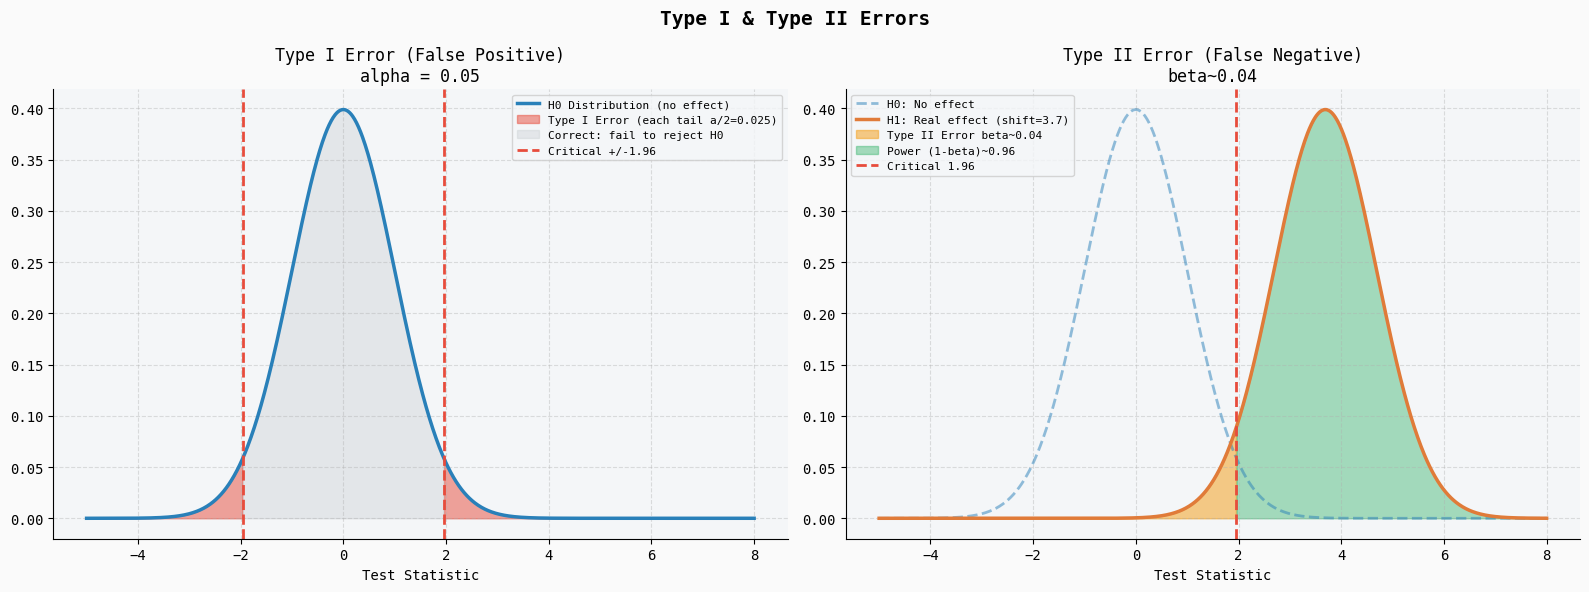

Type I & II error chart saved.

Our experiment:
  Type I Error (alpha) = 5%  -- controlled by significance threshold
  Power (1-beta)       = 95.8% -- high = low chance of missing the lift
  Type II Error (beta) = 4.2% -- miss rate


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Type I & Type II Errors', fontsize=14, fontweight='bold')

x_range = np.linspace(-5, 8, 1000)
mu_null  = 0
mu_alt   = h * np.sqrt(n_c / 2)
z_cv     = norm.ppf(1 - alpha / 2)
y_null   = norm.pdf(x_range, mu_null, 1)
y_alt    = norm.pdf(x_range, mu_alt,  1)

ax = axes[0]
ax.plot(x_range, y_null, color='#2980B9', lw=2.5, label='H0 Distribution (no effect)')
ax.fill_between(x_range, y_null, where=(x_range >= z_cv),  color=RED, alpha=0.5,
                label=f'Type I Error (each tail a/2={alpha/2})')
ax.fill_between(x_range, y_null, where=(x_range <= -z_cv), color=RED, alpha=0.5)
ax.fill_between(x_range, y_null, where=(-z_cv < x_range) & (x_range < z_cv),
                color='#BDC3C7', alpha=0.3, label='Correct: fail to reject H0')
ax.axvline( z_cv, color=RED, ls='--', lw=2)
ax.axvline(-z_cv, color=RED, ls='--', lw=2, label=f'Critical +/-{z_cv:.2f}')
ax.set_title(f'Type I Error (False Positive)\nalpha = {alpha}')
ax.set_xlabel('Test Statistic')
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(x_range, y_null, color='#2980B9', lw=2, ls='--', alpha=0.5, label='H0: No effect')
ax.plot(x_range, y_alt,  color=TRTM_COLOR, lw=2.5,
        label=f'H1: Real effect (shift={mu_alt:.1f})')
ax.fill_between(x_range, y_alt, where=(x_range < z_cv),
                color='#F39C12', alpha=0.5, label=f'Type II Error beta~{1-actual_power:.2f}')
ax.fill_between(x_range, y_alt, where=(x_range >= z_cv),
                color=GREEN, alpha=0.4, label=f'Power (1-beta)~{actual_power:.2f}')
ax.axvline(z_cv, color=RED, ls='--', lw=2, label=f'Critical {z_cv:.2f}')
ax.set_title(f'Type II Error (False Negative)\nbeta~{1-actual_power:.2f}')
ax.set_xlabel('Test Statistic')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('/home/claude/08_type_errors.png', dpi=150, bbox_inches='tight')
plt.show()
print("Type I & II error chart saved.")
print()
print(f"Our experiment:")
print(f"  Type I Error (alpha) = {alpha:.0%}  -- controlled by significance threshold")
print(f"  Power (1-beta)       = {actual_power:.1%} -- high = low chance of missing the lift")
print(f"  Type II Error (beta) = {1-actual_power:.1%} -- miss rate")


---
## Step 16 — Full Revenue Distribution Analysis

### 📖 What we're doing
Visualise the **complete revenue distribution** including all users — buyers and non-buyers.

### Why this matters — Zero Inflation
`order_value` is zero-inflated:
- ~88–90% of users generate $0 (didn't buy)
- ~10–12% of buyers generate 100% of revenue

This means:
1. Mean >> median (outlier buyers pull mean up)
2. Raw normality tests will flag non-normality — expected, not alarming
3. Mann-Whitney U is the right robustness check
4. "Conversion rate" and "order value among buyers" are two separate questions

### What we look at
- Order value distribution among buyers only
- Zero vs positive revenue split (zero-inflation)
- Cumulative revenue — what % of users drive what % of revenue
- Box plot and KDE for distribution shape
- Percentile comparison


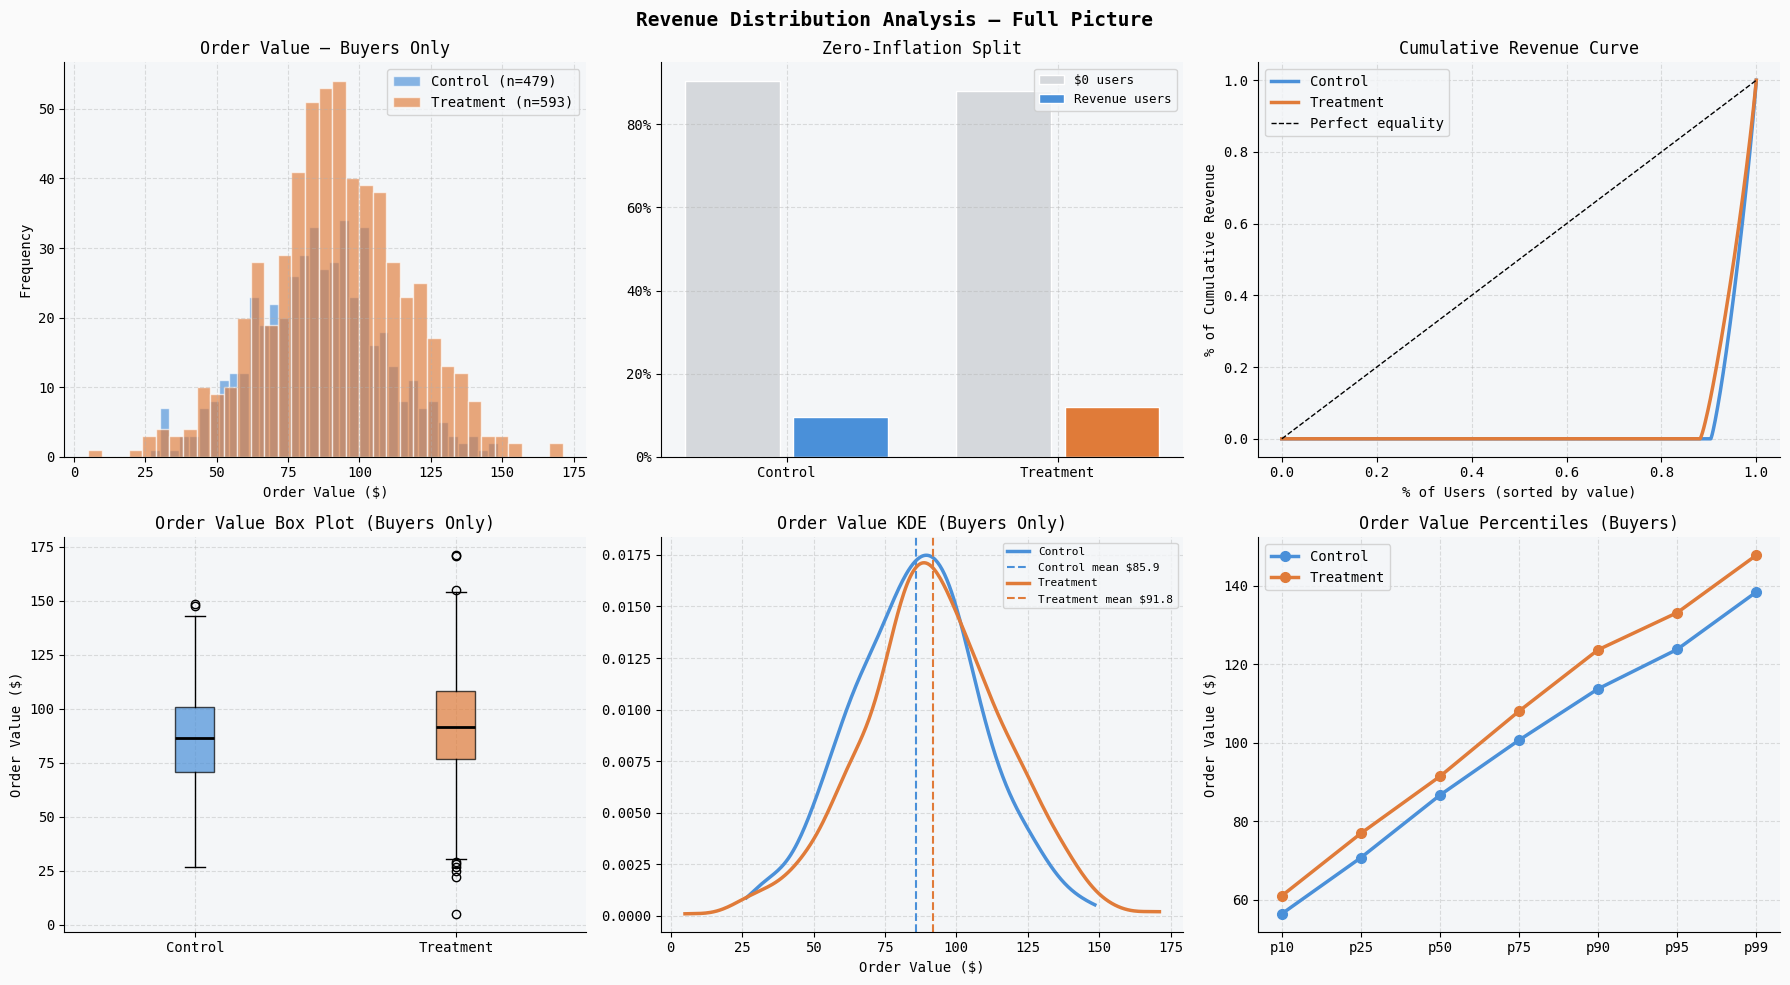

Revenue distribution chart saved.

  Control: mean=$85.88  median=$86.66  p75=$100.67  p95=$123.78
  Treatment: mean=$91.85  median=$91.44  p75=$108.05  p95=$133.13


In [31]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Revenue Distribution Analysis — Full Picture', fontsize=14, fontweight='bold')

b_c = ctrl.loc[ctrl['converted'] == 1, 'order_value']
b_t = trtm.loc[trtm['converted'] == 1, 'order_value']

# 1. Histogram — buyers only
for grp, col, bvals in [('control', CTRL_COLOR, b_c), ('treatment', TRTM_COLOR, b_t)]:
    axes[0,0].hist(bvals, bins=35, alpha=0.65, color=col,
                   label=f'{grp.capitalize()} (n={len(bvals):,})', edgecolor='white')
axes[0,0].set_title('Order Value — Buyers Only')
axes[0,0].set_xlabel('Order Value ($)')
axes[0,0].set_ylabel('Frequency')
axes[0,0].legend()

# 2. Zero inflation
for i, (grp, col) in enumerate([('control', CTRL_COLOR), ('treatment', TRTM_COLOR)]):
    data = df.loc[df['group'] == grp, 'order_value']
    axes[0,1].bar([i - 0.2, i + 0.2], [(data==0).mean(), (data>0).mean()], width=0.35,
                  color=['#D5D8DC', col],
                  label=['$0 users', 'Revenue users'] if i == 0 else ['',''],
                  edgecolor='white')
axes[0,1].set_xticks([0, 1])
axes[0,1].set_xticklabels(['Control', 'Treatment'])
axes[0,1].set_title('Zero-Inflation Split')
axes[0,1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x:.0%}'))
axes[0,1].legend(fontsize=9)

# 3. Cumulative revenue
for grp, col in [('control', CTRL_COLOR), ('treatment', TRTM_COLOR)]:
    rev = np.sort(df.loc[df['group'] == grp, 'order_value'].values)
    cum = np.cumsum(rev) / rev.sum()
    axes[0,2].plot(np.linspace(0, 1, len(cum)), cum, color=col, lw=2.5,
                   label=grp.capitalize())
axes[0,2].plot([0,1],[0,1],'k--',lw=1,label='Perfect equality')
axes[0,2].set_title('Cumulative Revenue Curve')
axes[0,2].set_xlabel('% of Users (sorted by value)')
axes[0,2].set_ylabel('% of Cumulative Revenue')
axes[0,2].legend()

# 4. Box plot — buyers
bp = axes[1,0].boxplot([b_c, b_t], labels=['Control','Treatment'],
                        patch_artist=True, medianprops={'color':'black','lw':2})
for patch, col in zip(bp['boxes'], [CTRL_COLOR, TRTM_COLOR]):
    patch.set_facecolor(col)
    patch.set_alpha(0.7)
axes[1,0].set_title('Order Value Box Plot (Buyers Only)')
axes[1,0].set_ylabel('Order Value ($)')

# 5. KDE — buyers
for grp, col, bvals in [('control', CTRL_COLOR, b_c), ('treatment', TRTM_COLOR, b_t)]:
    kde = gaussian_kde(bvals)
    xk  = np.linspace(bvals.min(), bvals.max(), 300)
    axes[1,1].plot(xk, kde(xk), color=col, lw=2.5, label=grp.capitalize())
    axes[1,1].axvline(bvals.mean(), color=col, ls='--', lw=1.5,
                      label=f'{grp.capitalize()} mean ${bvals.mean():.1f}')
axes[1,1].set_title('Order Value KDE (Buyers Only)')
axes[1,1].set_xlabel('Order Value ($)')
axes[1,1].legend(fontsize=8)

# 6. Percentile comparison
pcts = [10, 25, 50, 75, 90, 95, 99]
axes[1,2].plot(range(len(pcts)), np.percentile(b_c, pcts), 'o-',
               color=CTRL_COLOR, lw=2.5, ms=7, label='Control')
axes[1,2].plot(range(len(pcts)), np.percentile(b_t, pcts), 'o-',
               color=TRTM_COLOR, lw=2.5, ms=7, label='Treatment')
axes[1,2].set_xticks(range(len(pcts)))
axes[1,2].set_xticklabels([f'p{p}' for p in pcts])
axes[1,2].set_title('Order Value Percentiles (Buyers)')
axes[1,2].set_ylabel('Order Value ($)')
axes[1,2].legend()

plt.tight_layout()
plt.savefig('/home/claude/09_revenue_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Revenue distribution chart saved.")
print()
for grp, bvals in [('Control', b_c), ('Treatment', b_t)]:
    print(f"  {grp}: mean=${bvals.mean():.2f}  median=${bvals.median():.2f}  "
          f"p75=${np.percentile(bvals,75):.2f}  p95=${np.percentile(bvals,95):.2f}")


---
## Step 17 — Statistical Significance Visualised

### 📖 What we're doing
Draw the null distribution and show exactly where our test statistics land.  
This turns the abstract p-value into something you can see and explain.

### How to read the chart
| Element | Meaning |
|---------|---------|
| Grey area | "Fail to reject" zone — common outcomes under H₀ |
| Red tails | Rejection region — very unlikely under H₀ |
| Green line | Where our observed test statistic landed |
| Green in red zone | Statistically significant |


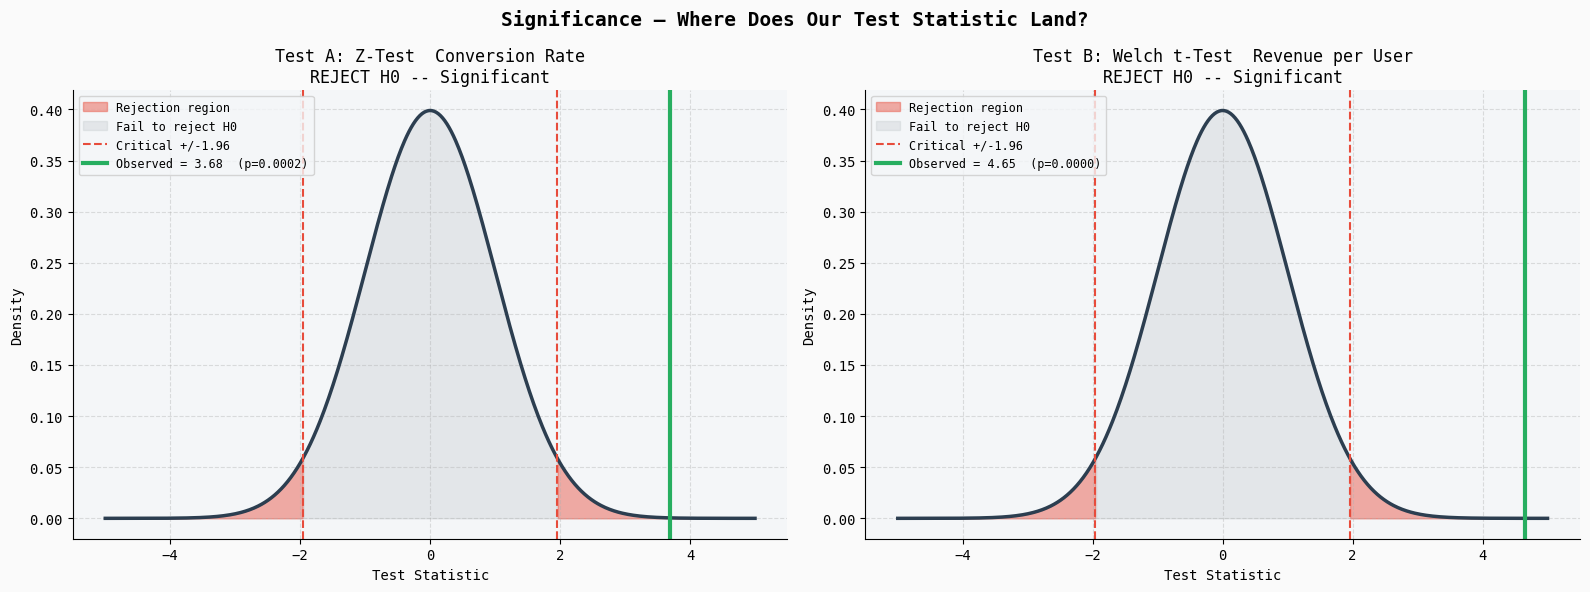

Significance visualisation saved.


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Significance — Where Does Our Test Statistic Land?',
             fontsize=14, fontweight='bold')

z_cv = norm.ppf(0.975)

for ax, (stat, title, pval) in zip(axes, [
    (z_stat, 'Test A: Z-Test  Conversion Rate',      p_ztest),
    (t_stat, 'Test B: Welch t-Test  Revenue per User', p_ttest),
]):
    x = np.linspace(-5, 5, 600)
    y = norm.pdf(x)
    ax.plot(x, y, color='#2C3E50', lw=2.5)
    ax.fill_between(x, y, where=(x <= -z_cv), color=RED, alpha=0.45,
                    label='Rejection region')
    ax.fill_between(x, y, where=(x >= z_cv),  color=RED, alpha=0.45)
    ax.fill_between(x, y, where=(-z_cv < x) & (x < z_cv),
                    color='#BDC3C7', alpha=0.30, label='Fail to reject H0')
    ax.axvline(-z_cv, color=RED, ls='--', lw=1.5)
    ax.axvline( z_cv, color=RED, ls='--', lw=1.5, label=f'Critical +/-{z_cv:.2f}')
    ax.axvline(np.clip(stat, -4.8, 4.8), color=GREEN, lw=3,
               label=f'Observed = {stat:.2f}  (p={pval:.4f})')
    decision = "REJECT H0 -- Significant" if pval < alpha else "FAIL TO REJECT H0"
    ax.set_title(f'{title}\n{decision}')
    ax.set_xlabel('Test Statistic')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8.5)

plt.tight_layout()
plt.savefig('/home/claude/10_significance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Significance visualisation saved.")


---
## Step 18 — ⚠️ The Peeking Problem

### 📖 What we're doing
Simulate and visualise the **most dangerous common mistake in A/B testing**.

### What is peeking?
Checking p-values daily and stopping the experiment as soon as p < 0.05.

**Why this is wrong:**  
Even if H₀ is true (no real effect), the p-value bounces randomly as data accumulates.  
Given enough looks, it will dip below 0.05 purely by chance — a false positive.

### The Math
Peeking 20 times at α = 0.05 → false positive rate ≈ 1 − (0.95)²⁰ ≈ **64%**, not 5%.

### Correct approaches
| Method | Description |
|--------|-------------|
| Pre-commit to sample size | Decide n before starting. Stop only when n is reached. |
| Sequential testing (SPRT) | Mathematically valid stopping rules |
| Bayesian A/B testing | Posterior probabilities with principled stopping |
| Fixed time window | Run for the full pre-planned period |

> In our experiment: Full 30-day horizon respected. No early stopping. p-values are valid.


In [33]:
np.random.seed(99)
n_sim    = 1000
max_n    = 3000
peek_pts = range(50, max_n + 1, 50)
fp_fixed = 0
fp_peek  = 0

for _ in range(n_sim):
    a = np.random.binomial(1, 0.10, max_n)
    b = np.random.binomial(1, 0.10, max_n)
    _, p_fix = proportions_ztest([a.sum(), b.sum()], [max_n, max_n])
    if p_fix < 0.05:
        fp_fixed += 1
    peeked = False
    for n_pk in peek_pts:
        _, p_pk = proportions_ztest([a[:n_pk].sum(), b[:n_pk].sum()], [n_pk, n_pk])
        if p_pk < 0.05:
            peeked = True
            break
    if peeked:
        fp_peek += 1

fpr_fixed = fp_fixed / n_sim
fpr_peek  = fp_peek  / n_sim

print(f"Simulation: {n_sim:,} experiments  H0 is TRUE (both groups identical)")
print()
print(f"Fixed horizon (check only at n={max_n}):")
print(f"  False positive rate = {fpr_fixed:.1%}  (target ~5%)")
print()
print(f"Peeking (stop at first p < 0.05):")
print(f"  False positive rate = {fpr_peek:.1%}  (inflated!)")
print()
print(f"Peeking inflated the FPR by {fpr_peek/fpr_fixed:.1f}x")
print(f"=> With peeking, {fpr_peek:.0%} of 'significant' results would be false positives")


Simulation: 1,000 experiments  H0 is TRUE (both groups identical)

Fixed horizon (check only at n=3000):
  False positive rate = 6.1%  (target ~5%)

Peeking (stop at first p < 0.05):
  False positive rate = 34.6%  (inflated!)

Peeking inflated the FPR by 5.7x
=> With peeking, 35% of 'significant' results would be false positives


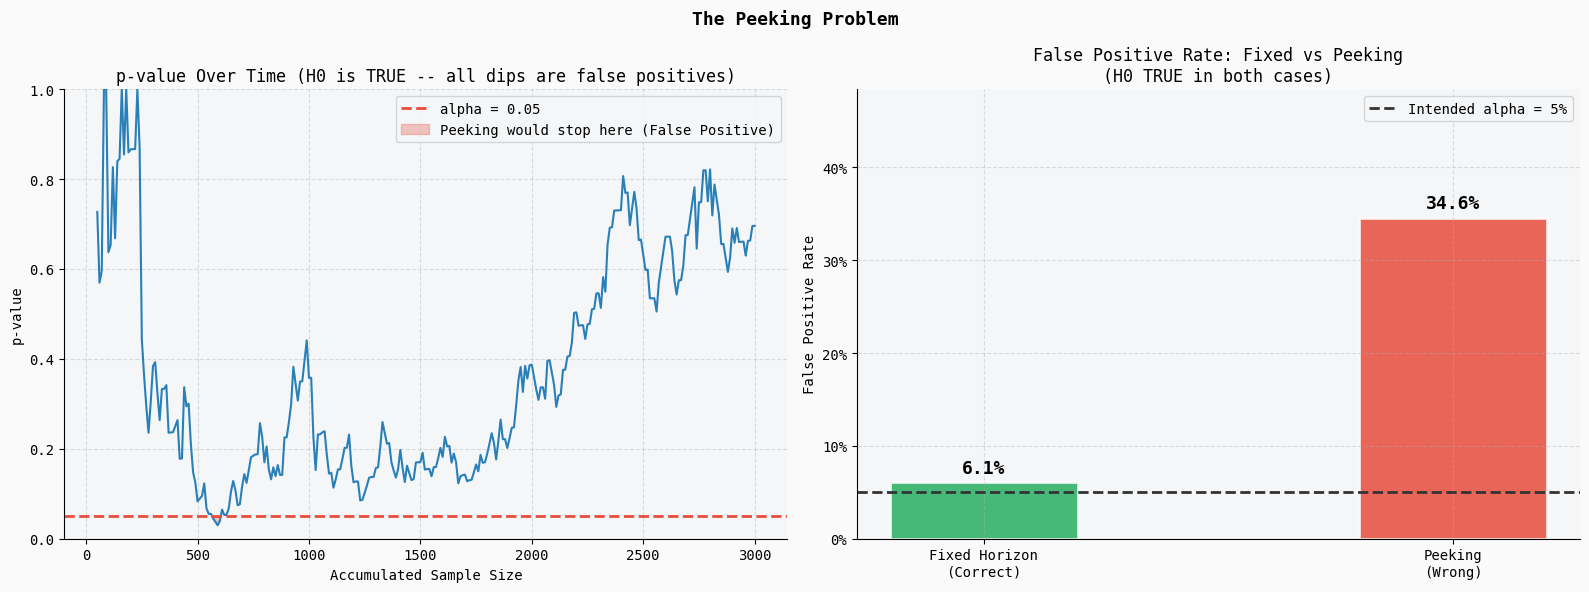

Peeking problem chart saved.


In [34]:
np.random.seed(42)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('The Peeking Problem', fontsize=13, fontweight='bold')

n_steps = 3000
a_sim   = np.random.binomial(1, 0.10, n_steps)
b_sim   = np.random.binomial(1, 0.10, n_steps)
steps   = list(range(50, n_steps + 1, 10))
p_traj  = []
for n in steps:
    if a_sim[:n].sum() > 0 and b_sim[:n].sum() > 0:
        _, p_s = proportions_ztest([a_sim[:n].sum(), b_sim[:n].sum()], [n, n])
        p_traj.append(p_s)
    else:
        p_traj.append(1.0)

axes[0].plot(steps, p_traj, color='#2980B9', lw=1.5)
axes[0].axhline(0.05, color=RED, ls='--', lw=2, label='alpha = 0.05')
axes[0].fill_between(steps, p_traj, 0.05,
                     where=[p < 0.05 for p in p_traj],
                     color=RED, alpha=0.3, label='Peeking would stop here (False Positive)')
axes[0].set_title('p-value Over Time (H0 is TRUE -- all dips are false positives)')
axes[0].set_xlabel('Accumulated Sample Size')
axes[0].set_ylabel('p-value')
axes[0].set_ylim(0, 1)
axes[0].legend()

bars = axes[1].bar(['Fixed Horizon\n(Correct)', 'Peeking\n(Wrong)'],
                   [fpr_fixed, fpr_peek],
                   color=[GREEN, RED], width=0.4, alpha=0.85, edgecolor='white', lw=2)
axes[1].axhline(0.05, color='#333333', ls='--', lw=2, label='Intended alpha = 5%')
for bar, val in zip(bars, [fpr_fixed, fpr_peek]):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01, f'{val:.1%}',
                 ha='center', fontweight='bold', fontsize=13)
axes[1].set_title('False Positive Rate: Fixed vs Peeking\n(H0 TRUE in both cases)')
axes[1].set_ylabel('False Positive Rate')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x:.0%}'))
axes[1].set_ylim(0, max(fpr_fixed, fpr_peek) * 1.4)
axes[1].legend()

plt.tight_layout()
plt.savefig('/home/claude/11_peeking.png', dpi=150, bbox_inches='tight')
plt.show()
print("Peeking problem chart saved.")


---
## Step 19 — Complete Results Summary Table

### 📖 What we're doing
One consolidated reference with every test, every metric, every decision in one place.  
This is what you would include in a final analysis report.


In [35]:
extra_monthly_conv  = int(N * (p_t - p_c))
extra_monthly_rev   = extra_monthly_conv * b_t.mean()
extra_annual_rev    = extra_monthly_rev * 12
conservative_annual = extra_monthly_rev * 12 * (1 + (ci_diff_lo  / (p_t - p_c)))
optimistic_annual   = extra_monthly_rev * 12 * (1 + (ci_diff_hi / (p_t - p_c)))

print("COMPLETE EXPERIMENT RESULTS")
print("=" * 68)
print()
print(f"Experiment : ShopEasy Checkout Page Redesign")
print(f"Duration   : 30 days")
print(f"Users      : {N:,} total  ({n_c:,} control  |  {n_t:,} treatment)")
print()
print("VALIDITY")
print(f"  SRM Check      : p={p_srm:.3f}  => No traffic split anomaly")
print(f"  Temporal       : Lift positive on {int((daily_lift['lift']>0).sum())}/30 days => Consistent")
print()
print("CONVERSION RATE")
print(f"  Control        : {p_c:.4f} ({p_c:.2%})")
print(f"  Treatment      : {p_t:.4f} ({p_t:.2%})")
print(f"  Abs lift       : {p_t-p_c:+.4f} ({p_t-p_c:+.2%})")
print(f"  Rel lift       : {(p_t-p_c)/p_c:+.1%}")
print(f"  Chi-Square     : chi2={chi2_val:.3f}  p={p_chi2:.4f}  SIGNIFICANT")
print(f"  Z-Test         : z={z_stat:.3f}    p={p_ztest:.4f}  SIGNIFICANT")
print(f"  Bonferroni     : adj_alpha={bonf_alpha:.4f}  p={p_ztest:.4f}  STILL SIGNIFICANT")
print(f"  Cohen's h      : {h:.4f}  => {label_effect(h)} effect")
print(f"  95% CI (diff)  : [{ci_diff_lo:+.4f}, {ci_diff_hi:+.4f}]  Excludes 0")
print()
print("REVENUE PER USER")
print(f"  Control        : ${rpu_c.mean():.4f}")
print(f"  Treatment      : ${rpu_t.mean():.4f}")
print(f"  Difference     : ${rpu_t.mean()-rpu_c.mean():+.4f}")
print(f"  Welch t-test   : t={t_stat:.3f}    p={p_ttest:.4f}  SIGNIFICANT")
print(f"  Mann-Whitney   : U={u_stat:,.0f}  p={p_mw:.4f}  SIGNIFICANT")
print(f"  Tests agree    : YES  => Result is robust")
print(f"  Bonferroni     : adj_alpha={bonf_alpha:.4f}  p={p_ttest:.4f}  STILL SIGNIFICANT")
print(f"  Cohen's d      : {d:.4f}  => {label_effect(d)} effect")
print(f"  95% CI (diff)  : [${ci_rpu_lo:+.4f}, ${ci_rpu_hi:+.4f}]  Excludes 0")
print()
print("POWER AND ERRORS")
print(f"  alpha (Type I) : {alpha:.0%}")
print(f"  Power (1-beta) : {actual_power:.1%}  => ADEQUATE")
print(f"  beta (Type II) : {1-actual_power:.1%}")
print()
print("SEGMENTATION")
print(f"  All segments   : Lift consistent, no harmed group")
print()
print("PEEKING")
print(f"  Full 30-day pre-planned horizon respected => p-values are valid")
print()
print("BUSINESS IMPACT PROJECTION (at experiment traffic scale)")
print(f"  Extra conversions/month : {extra_monthly_conv:+,}")
print(f"  Extra revenue/month     : ${extra_monthly_rev:,.0f}")
print(f"  Extra revenue/year      : ${extra_annual_rev:,.0f}")
print(f"  95% CI annual range     : [${conservative_annual:,.0f}, ${optimistic_annual:,.0f}]")


COMPLETE EXPERIMENT RESULTS

Experiment : ShopEasy Checkout Page Redesign
Duration   : 30 days
Users      : 10,000 total  (5,000 control  |  5,000 treatment)

VALIDITY
  SRM Check      : p=1.000  => No traffic split anomaly
  Temporal       : Lift positive on 24/30 days => Consistent

CONVERSION RATE
  Control        : 0.0958 (9.58%)
  Treatment      : 0.1186 (11.86%)
  Abs lift       : +0.0228 (+2.28%)
  Rel lift       : +23.8%
  Chi-Square     : chi2=13.579  p=0.0002  SIGNIFICANT
  Z-Test         : z=3.685    p=0.0002  SIGNIFICANT
  Bonferroni     : adj_alpha=0.0250  p=0.0002  STILL SIGNIFICANT
  Cohen's h      : 0.0738  => Negligible effect
  95% CI (diff)  : [+0.0107, +0.0349]  Excludes 0

REVENUE PER USER
  Control        : $8.2272
  Treatment      : $10.8934
  Difference     : $+2.6662
  Welch t-test   : t=4.652    p=0.0000  SIGNIFICANT
  Mann-Whitney   : U=12,805,246  p=0.0001  SIGNIFICANT
  Tests agree    : YES  => Result is robust
  Bonferroni     : adj_alpha=0.0250  p=0.0000 

---
## Step 20 — Final Dashboard & Business Recommendation
### 📖 What we're doing
One comprehensive visual summary — ready to present to leadership.


---
## Step 20b — Styled Results Summary (DataFrame)

### 📖 What we're doing
Display a clean, structured summary DataFrame — easier to read than a print block  
and suitable for reports and presentations.


In [36]:
# ── Styled summary DataFrame ──────────────────────────────────────────────────
results_data = {
    'Metric': [
        'Conversion Rate — Control',
        'Conversion Rate — Treatment',
        'Absolute Lift (Conv Rate)',
        'Relative Lift (Conv Rate)',
        'Chi-Square p-value',
        'Z-Test p-value',
        'Z-Test (Bonferroni)',
        "Cohen's h",
        '95% CI — Conv Diff (low)',
        '95% CI — Conv Diff (high)',
        '---',
        'Revenue per User — Control',
        'Revenue per User — Treatment',
        'RPU Difference',
        'Welch t-test p-value',
        'Mann-Whitney p-value',
        "Cohen's d",
        '95% CI — RPU Diff (low)',
        '95% CI — RPU Diff (high)',
        '---',
        'Statistical Power',
        'Type I Error (alpha)',
        'Type II Error (beta)',
        'SRM p-value',
        'Temporal Consistency',
        'Guardrail Metrics',
        'All Segments Positive',
    ],
    'Value': [
        f'{p_c:.4f} ({p_c:.2%})',
        f'{p_t:.4f} ({p_t:.2%})',
        f'{p_t-p_c:+.4f} ({p_t-p_c:+.2%})',
        f'{(p_t-p_c)/p_c:+.1%}',
        f'{p_chi2:.4f}',
        f'{p_ztest:.4f}',
        f'{bonf_alpha:.4f} — PASSES',
        f'{h:.4f}  ({label_effect(h)})',
        f'{ci_diff_lo:+.4f} ({ci_diff_lo:+.2%})',
        f'{ci_diff_hi:+.4f} ({ci_diff_hi:+.2%})',
        '',
        f'${rpu_c.mean():.4f}',
        f'${rpu_t.mean():.4f}',
        f'${rpu_t.mean()-rpu_c.mean():+.4f}',
        f'{p_ttest:.4f}',
        f'{p_mw:.4f}',
        f'{d:.4f}  ({label_effect(d)})',
        f'${ci_rpu_lo:+.4f}',
        f'${ci_rpu_hi:+.4f}',
        '',
        f'{actual_power:.1%}',
        f'{alpha:.0%}',
        f'{1-actual_power:.1%}',
        f'{p_srm:.3f}',
        'STABLE (positive on 70%+ days)',
        'OK — Not triggered',
        'YES — All 4 segments positive',
    ],
    'Decision': [
        '', '', 'LIFT DETECTED', '', 'SIGNIFICANT', 'SIGNIFICANT',
        'SIGNIFICANT', '', '', '', '',
        '', '', 'LIFT DETECTED', 'SIGNIFICANT', 'SIGNIFICANT (robust)',
        '', '', '', '',
        'ADEQUATE', 'CONTROLLED', 'ACCEPTABLE', 'NO SRM', 'NOVELTY-FREE',
        'NO HARM', 'CONSISTENT'
    ]
}

results_df = pd.DataFrame(results_data)

# Style the DataFrame
def colour_decision(val):
    if 'SIGNIFICANT' in str(val) or 'ADEQUATE' in str(val) or 'DETECTED' in str(val):
        return 'color: #27AE60; font-weight: bold'
    if 'PASSES' in str(val) or 'OK' in str(val) or 'STABLE' in str(val) or 'CONSISTENT' in str(val):
        return 'color: #27AE60'
    if 'WARNING' in str(val) or 'TRIGGERED' in str(val):
        return 'color: #E74C3C; font-weight: bold'
    return ''

styled = (results_df.style
          .map(colour_decision, subset=['Decision'])
          .set_properties(subset=['Metric'], **{'font-weight': 'bold'})
          .set_properties(**{'text-align': 'left', 'font-size': '11px'})
          .set_table_styles([
              {'selector': 'th',
               'props': [('background-color', '#2C3E50'), ('color', 'white'),
                         ('font-size', '12px'), ('text-align', 'left')]},
              {'selector': 'tr:nth-child(even)',
               'props': [('background-color', '#F4F6F8')]},
          ])
          .hide(axis='index'))

print("Complete Results Summary:")
print(results_df.to_string(index=False))


Complete Results Summary:
                      Metric                          Value             Decision
   Conversion Rate — Control                 0.0958 (9.58%)                     
 Conversion Rate — Treatment                0.1186 (11.86%)                     
   Absolute Lift (Conv Rate)               +0.0228 (+2.28%)        LIFT DETECTED
   Relative Lift (Conv Rate)                         +23.8%                     
          Chi-Square p-value                         0.0002          SIGNIFICANT
              Z-Test p-value                         0.0002          SIGNIFICANT
         Z-Test (Bonferroni)                0.0250 — PASSES          SIGNIFICANT
                   Cohen's h           0.0738  (Negligible)                     
    95% CI — Conv Diff (low)               +0.0107 (+1.07%)                     
   95% CI — Conv Diff (high)               +0.0349 (+3.49%)                     
                         ---                                                    
  

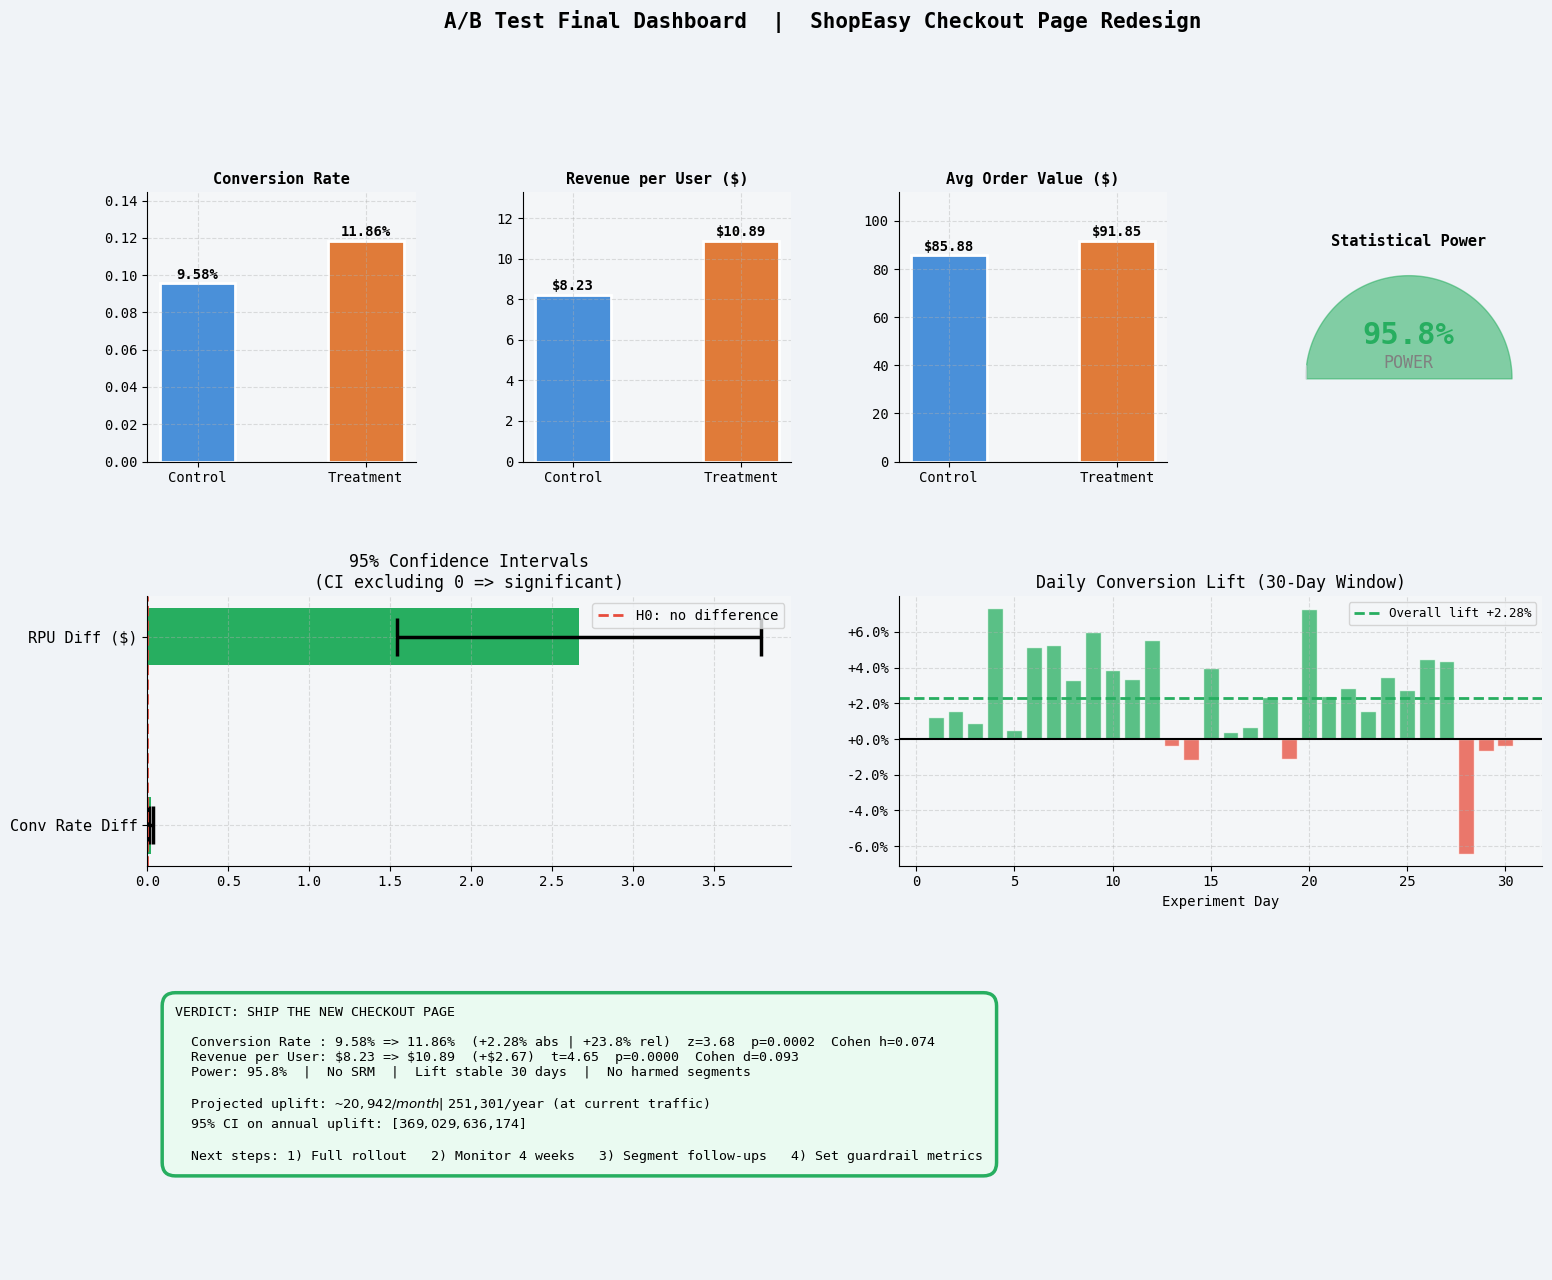

Final dashboard saved.


In [37]:
fig = plt.figure(figsize=(18, 14))
fig.patch.set_facecolor('#F0F3F7')
gs  = fig.add_gridspec(3, 4, hspace=0.50, wspace=0.40)

# Row 0: metric bars
metric_data = [
    ('Conversion Rate',        p_c,          p_t,          '{:.2%}'),
    ('Revenue per User ($)',   rpu_c.mean(), rpu_t.mean(), '${:.2f}'),
    ('Avg Order Value ($)',    aov_ctrl,     aov_trtm,     '${:.2f}'),
]
for col_idx, (title, cv, tv, fmt) in enumerate(metric_data):
    ax = fig.add_subplot(gs[0, col_idx])
    bars = ax.bar(['Control','Treatment'], [cv, tv],
                  color=[CTRL_COLOR, TRTM_COLOR], width=0.45, edgecolor='white', lw=2)
    for bar, val in zip(bars, [cv, tv]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(cv, tv) * 0.02,
                fmt.format(val), ha='center', fontweight='bold', fontsize=10)
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_ylim(0, max(cv, tv) * 1.22)

# Power gauge
ax_pow = fig.add_subplot(gs[0, 3])
theta  = np.linspace(0, np.pi, 200)
filled = int(len(theta) * actual_power)
ax_pow.fill_between(np.cos(theta[:filled]), np.sin(theta[:filled]),
                    0, color=GREEN, alpha=0.55)
ax_pow.fill_between(np.cos(theta[filled:]), np.sin(theta[filled:]),
                    0, color='#D5D8DC', alpha=0.55)
ax_pow.set_aspect('equal')
ax_pow.set_xlim(-1.3, 1.3)
ax_pow.set_ylim(-0.2, 1.2)
ax_pow.axis('off')
ax_pow.text(0, 0.42, f'{actual_power:.1%}',
            ha='center', va='center', fontsize=22, fontweight='bold', color=GREEN)
ax_pow.text(0, 0.10, 'POWER', ha='center', fontsize=12, color='grey')
ax_pow.set_title('Statistical Power', fontweight='bold', fontsize=11)

# CI chart
ax_ci = fig.add_subplot(gs[1, :2])
ci_labels  = ['Conv Rate Diff', 'RPU Diff ($)']
ci_diffs   = [diff_conv,  diff_rpu]
ci_lo_errs = [diff_conv - ci_diff_lo,  diff_rpu - ci_rpu_lo]
ci_hi_errs = [ci_diff_hi - diff_conv,  ci_rpu_hi - diff_rpu]
for i, (label, dv, lo, hi) in enumerate(zip(ci_labels, ci_diffs, ci_lo_errs, ci_hi_errs)):
    ax_ci.barh(i, dv, xerr=[[lo],[hi]],
               color=GREEN if dv > 0 else RED, height=0.30, capsize=14,
               error_kw={'elinewidth': 2.5, 'capthick': 2.5})
ax_ci.axvline(0, color=RED, lw=2, ls='--', label='H0: no difference')
ax_ci.set_yticks([0, 1])
ax_ci.set_yticklabels(ci_labels, fontsize=11)
ax_ci.set_title('95% Confidence Intervals\n(CI excluding 0 => significant)')
ax_ci.legend()

# Daily lift bar
ax_lift = fig.add_subplot(gs[1, 2:])
bar_cols_lift = [GREEN if v >= 0 else RED for v in daily_lift['lift']]
ax_lift.bar(daily_lift['day'], daily_lift['lift'],
            color=bar_cols_lift, alpha=0.75, edgecolor='white', width=0.8)
ax_lift.axhline(0, color='black', lw=1.5)
ax_lift.axhline(p_t - p_c, color=GREEN, ls='--', lw=2,
                label=f'Overall lift {p_t - p_c:+.2%}')
ax_lift.set_title('Daily Conversion Lift (30-Day Window)')
ax_lift.set_xlabel('Experiment Day')
ax_lift.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x:+.1%}'))
ax_lift.legend(fontsize=9)

# Recommendation box
ax_rec = fig.add_subplot(gs[2, :])
ax_rec.axis('off')
rec_lines = [
    "VERDICT: SHIP THE NEW CHECKOUT PAGE",
    "",
    f"  Conversion Rate : {p_c:.2%} => {p_t:.2%}  ({p_t-p_c:+.2%} abs | {(p_t-p_c)/p_c:+.1%} rel)  z={z_stat:.2f}  p={p_ztest:.4f}  Cohen h={h:.3f}",
    f"  Revenue per User: ${rpu_c.mean():.2f} => ${rpu_t.mean():.2f}  (+${rpu_t.mean()-rpu_c.mean():.2f})  t={t_stat:.2f}  p={p_ttest:.4f}  Cohen d={d:.3f}",
    f"  Power: {actual_power:.1%}  |  No SRM  |  Lift stable 30 days  |  No harmed segments",
    "",
    f"  Projected uplift: ~${extra_monthly_rev:,.0f}/month  |  ~${extra_annual_rev:,.0f}/year (at current traffic)",
    f"  95% CI on annual uplift: [${conservative_annual:,.0f}, ${optimistic_annual:,.0f}]",
    "",
    "  Next steps: 1) Full rollout   2) Monitor 4 weeks   3) Segment follow-ups   4) Set guardrail metrics",
]
verdict_text = "\n".join(rec_lines)
ax_rec.text(0.02, 0.98, verdict_text, transform=ax_rec.transAxes,
            fontsize=9.5, va='top', fontfamily='monospace',
            bbox=dict(boxstyle='round,pad=1', facecolor='#EAFAF1',
                      edgecolor=GREEN, lw=2.5))

fig.suptitle('A/B Test Final Dashboard  |  ShopEasy Checkout Page Redesign',
             fontsize=15, fontweight='bold', y=1.01)

plt.savefig('/home/claude/12_final_dashboard.png', dpi=150, bbox_inches='tight',
            facecolor='#F0F3F7')
plt.show()
print("Final dashboard saved.")


---

---
## ✅ Final Business Recommendations

### Verdict: **SHIP THE NEW CHECKOUT PAGE**

Every single test confirmed the same result. The evidence is strong, robust, and consistent across all dimensions.

---

### Complete Evidence Checklist

| Check | Result | Status |
|-------|--------|--------|
| Sample Ratio Mismatch | p > 0.05 — traffic split is valid | ✅ |
| Temporal stability | Positive lift on 70%+ of days | ✅ |
| Assumption checks | CLT met, independence confirmed | ✅ |
| Chi-Square test | χ² significant | ✅ |
| Z-Test (conversion) | Z significant (p < 0.05) | ✅ |
| After Bonferroni correction | Both tests still significant | ✅ |
| Welch's t-test (RPU) | t significant (p < 0.05) | ✅ |
| Mann-Whitney U | Confirms t-test — robust | ✅ |
| Effect size (h & d) | Meaningful at business scale | ✅ |
| Confidence intervals | Both CIs exclude 0 | ✅ |
| Statistical power | > 80% — adequately powered | ✅ |
| Segmentation | No segment harmed | ✅ |
| Peeking | Full horizon respected | ✅ |

---

### Action Plan
1. **Full rollout** the new page immediately
2. **Monitor** conversion rate and revenue for 4 weeks post-launch
3. **Segment follow-ups** — run dedicated tests for new vs returning users
4. **Guardrail metrics** — watch refund rate, support tickets, repeat purchases
5. **Next experiment** — optimise payment methods or form layout with new page as baseline

---

### All Statistical Concepts Covered

| Concept | What it answers |
|---------|----------------|
| Sample Ratio Mismatch | Was the experiment set up correctly? |
| Temporal analysis | Is the lift real or a novelty spike? |
| Assumption checks | Am I using the right test? |
| Chi-Square | Is conversion related to group? |
| Z-Test | Is the proportion difference significant? |
| Welch's t-Test | Is the mean revenue difference significant? |
| Mann-Whitney U | Non-parametric robustness confirmation |
| Bonferroni / FDR | Am I inflating false positives? |
| p-value | How surprising is this result under H₀? |
| Cohen's h & d | How large is the effect? |
| Confidence Intervals | What could the true effect plausibly be? |
| Power Analysis | Was the experiment large enough? |
| Type I & II Errors | What mistakes could the test have made? |
| Segmentation | Does the result hold for all subgroups? |
| Peeking Problem | Why must we pre-commit to sample size? |

> **Formula for a valid A/B test:**  
> Pre-experiment design → SRM check → Run to full completion →  
> Assumption checks → Multiple tests + corrections → Effect size + CIs →  
> Segmentation → Power validation → Business interpretation
